## Import

In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV 

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, max_error

import pandas as pd

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from ML.utils.Model_trainer import Model_trainer
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/fine_tuned_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/fine_tuned_models/"
tag = "mass_smaller_14"
output_parameters = ["mass", "radius"]
categories_name = ["label"]

In [4]:
override = True
use_preds = False
save = True
show = True

In [5]:
def display_grid_search(gscv):
    df = pd.DataFrame.from_dict(gscv.cv_results_)
    pd.set_option('display.max_columns', None)
    display(df)
    print(f"Best parameters {gscv.best_params_}")
    print(f"Best score {gscv.best_score_}")

## Data preparation

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)


# Faire le fine-tuning

Random forest with Base, Decision tree with scale_quantile and KNN with scale_standard

## Fine-tuning

### Decision tree

#### Tuning the criterion and splitter parameter

In [10]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'splitter' : ["best", "random"]
            }

gscv_dt_1 = GridSearchCV(DecisionTreeRegressor(),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_dt_1.fit(X_train,y_train)
display_grid_search(gscv_dt_1)

Fitting 10 folds for each of 4 candidates, totalling 40 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_splitter,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.805292,0.012457,0.014008,0.002873,squared_error,best,"{'criterion': 'squared_error', 'splitter': 'be...",-0.022294,-0.021500,-0.019966,-0.022499,-0.020748,-0.019420,-0.020292,-0.022661,-0.021374,-0.020846,-0.021160,0.001047,1,-0.004611,-0.004466,-0.004169,-0.004620,-0.004345,-0.004234,-0.004358,-0.004698,-0.004418,-0.004476,-0.004439,0.000162,1
1,0.339079,0.015495,0.015286,0.001670,squared_error,random,"{'criterion': 'squared_error', 'splitter': 'ra...",-0.022657,-0.024583,-0.023678,-0.023419,-0.021729,-0.022294,-0.022223,-0.023570,-0.022035,-0.022869,-0.022906,0.000846,2,-0.004881,-0.004934,-0.004856,-0.004995,-0.004724,-0.004707,-0.004811,-0.004894,-0.004740,-0.004799,-0.004834,0.000090,2
2,0.799711,0.015181,0.012587,0.004024,friedman_mse,best,"{'criterion': 'friedman_mse', 'splitter': 'best'}",-0.024290,-0.023958,-0.023052,-0.025318,-0.022496,-0.024133,-0.022525,-0.025677,-0.025109,-0.023533,-0.024009,0.001069,3,-0.005261,-0.005173,-0.004910,-0.005374,-0.004950,-0.005209,-0.005065,-0.005488,-0.005440,-0.005293,-0.005216,0.000186,3
3,0.328418,0.019732,0.012626,0.003042,friedman_mse,random,"{'criterion': 'friedman_mse', 'splitter': 'ran...",-0.035126,-0.024874,-0.024528,-0.025763,-0.025540,-0.023196,-0.023489,-0.026036,-0.025022,-0.023125,-0.025670,0.003306,4,-0.005517,-0.005327,-0.005145,-0.005625,-0.005541,-0.005146,-0.005234,-0.005589,-0.005410,-0.005333,-0.005387,0.000169,4


Best parameters {'criterion': 'squared_error', 'splitter': 'best'}
Best score -0.02116004137257151


#### Tuning the max_depth, min_samples_split and min_samples_leaf parameter

In [11]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_depth' : [25, 50, 75, 100, None],
             'min_samples_split' : [2, 4, 6, 8, 10],
             'min_samples_leaf' : [1, 2, 3, 4, 5],
            }

gscv_dt_2 = GridSearchCV(DecisionTreeRegressor(criterion="squared_error",
                                               splitter="best"
                                               ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_dt_2.fit(X_train,y_train)
display_grid_search(gscv_dt_2)

Fitting 10 folds for each of 125 candidates, totalling 1250 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.926098,0.022195,0.017352,0.004888,25,1,2,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.021099,-0.021980,-0.020154,-0.022222,-0.020404,-0.019596,-0.019606,-0.023548,-0.021831,-0.020570,-0.021101,0.001213,1,-0.004474,-0.004509,-0.004203,-0.004608,-0.004333,-0.004240,-0.004267,-0.004805,-0.004469,-0.004452,-0.004436,0.000175,2
1,0.823885,0.013013,0.012608,0.003281,25,1,4,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.022155,-0.022162,-0.021016,-0.022607,-0.020571,-0.020322,-0.020705,-0.023479,-0.022432,-0.021495,-0.021694,0.000981,12,-0.004756,-0.004733,-0.004484,-0.004859,-0.004560,-0.004566,-0.004564,-0.005013,-0.004756,-0.004763,-0.004705,0.000154,8
2,0.782107,0.016943,0.011802,0.001663,25,1,6,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.023172,-0.022442,-0.021436,-0.023719,-0.021829,-0.020668,-0.021721,-0.024270,-0.023019,-0.021966,-0.022424,0.001054,25,-0.005208,-0.005005,-0.004858,-0.005296,-0.005029,-0.004861,-0.005053,-0.005420,-0.005169,-0.005177,-0.005108,0.000172,25
3,0.886917,0.022566,0.011855,0.002206,25,1,8,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.023774,-0.023665,-0.022193,-0.023870,-0.023120,-0.021613,-0.022546,-0.025276,-0.023887,-0.022673,-0.023262,0.000999,49,-0.005677,-0.005526,-0.005360,-0.005765,-0.005578,-0.005364,-0.005547,-0.005940,-0.005726,-0.005639,-0.005612,0.000170,33
4,0.828722,0.022769,0.010816,0.002160,25,1,10,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.025267,-0.024533,-0.023922,-0.025116,-0.023858,-0.023204,-0.023693,-0.026861,-0.024841,-0.023566,-0.024486,0.001030,61,-0.006382,-0.006075,-0.006095,-0.006399,-0.006214,-0.006099,-0.006201,-0.006625,-0.006371,-0.006334,-0.006280,0.000166,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,0.769155,0.008320,0.009765,0.001199,None,5,2,"{'max_depth': None, 'min_samples_leaf': 5, 'mi...",-0.026630,-0.026456,-0.026400,-0.027240,-0.026156,-0.024898,-0.025909,-0.028049,-0.026370,-0.025681,-0.026379,0.000810,119,-0.007707,-0.007497,-0.007530,-0.007801,-0.007688,-0.007319,-0.007461,-0.007967,-0.007716,-0.007698,-0.007638,0.000178,110
121,0.780117,0.010622,0.008937,0.000945,None,5,4,"{'max_depth': None, 'min_samples_leaf': 5, 'mi...",-0.026660,-0.026440,-0.026396,-0.027227,-0.026110,-0.024911,-0.025905,-0.028141,-0.026373,-0.025715,-0.026388,0.000824,122,-0.007715,-0.007499,-0.007539,-0.007817,-0.007687,-0.007314,-0.007466,-0.007972,-0.007713,-0.007696,-0.007642,0.000180,123
122,0.776587,0.008464,0.008806,0.000674,None,5,6,"{'max_depth': None, 'min_samples_leaf': 5, 'mi...",-0.026616,-0.026360,-0.026442,-0.027236,-0.026105,-0.024796,-0.025794,-0.028086,-0.026309,-0.025653,-0.026340,0.000846,104,-0.007710,-0.007491,-0.007544,-0.007819,-0.007683,-0.007300,-0.007450,-0.007959,-0.007699,-0.007690,-0.007635,0.000181,101
123,0.777067,

Best parameters {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -0.021101054616844066


#### Tuning the max_features and max_leaf_nodes parameter

In [12]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_features' : ["sqrt", "log2", None],
             'max_leaf_nodes' : [50, 100, 150, 200, None]
            }

gscv_dt_3 = GridSearchCV(DecisionTreeRegressor(criterion="squared_error",
                                               splitter="best",
                                               max_depth=25,
                                               min_samples_leaf=1,
                                               min_samples_split=2
                                               ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_dt_3.fit(X_train,y_train)
display_grid_search(gscv_dt_3)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.344597,0.019566,0.003989,0.000621,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-0.267695,-0.272463,-0.372934,-0.302600,-0.362492,-0.377485,-0.260360,-0.280216,-0.294397,-0.334214,-0.312485,0.043178,15,-0.184076,-0.173977,-0.212927,-0.190368,-0.223012,-0.241254,-0.159793,-0.168342,-0.212586,-0.212775,-0.197911,0.025138,15
1,0.350325,0.017683,0.004087,0.000533,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.179846,-0.186082,-0.228219,-0.231615,-0.199997,-0.214708,-0.199758,-0.204622,-0.201139,-0.207154,-0.205314,0.015503,11,-0.112213,-0.116606,-0.134868,-0.144120,-0.128474,-0.128208,-0.127642,-0.133136,-0.120250,-0.130898,-0.127642,0.008832,11
2,0.410910,0.031419,0.004728,0.000799,sqrt,150,"{'max_features': 'sqrt', 'max_leaf_nodes': 150}",-0.215756,-0.185354,-0.195323,-0.162128,-0.167312,-0.205838,-0.163961,-0.196849,-0.195893,-0.211001,-0.189942,0.018591,10,-0.130223,-0.111230,-0.118949,-0.102936,-0.103716,-0.123952,-0.105602,-0.122506,-0.116601,-0.132215,-0.116793,0.010129,10
3,0.490284,0.031824,0.004705,0.001006,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-0.152425,-0.153912,-0.169687,-0.173257,-0.169284,-0.176066,-0.175497,-0.183572,-0.163161,-0.157869,-0.167473,0.009799,8,-0.099212,-0.094481,-0.103943,-0.101490,-0.099973,-0.102779,-0.107466,-0.113126,-0.098969,-0.098349,-0.101979,0.004992,7
4,0.592029,0.020736,0.016362,0.002965,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.034401,-0.030038,-0.031382,-0.035944,-0.035698,-0.032810,-0.035411,-0.030764,-0.034006,-0.034113,-0.033457,0.002008,3,-0.006866,-0.005979,-0.006577,-0.006780,-0.006625,-0.006980,-0.006936,-0.006513,-0.007120,-0.006919,-0.006729,0.000310,3
5,0.320359,0.016021,0.004597,0.000445,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-0.282892,-0.261669,-0.302828,-0.291205,-0.268948,-0.264722,-0.257717,-0.284609,-0.311526,-0.262111,-0.278823,0.017789,14,-0.176825,-0.167976,-0.199815,-0.177246,-0.174173,-0.167818,-0.159174,-0.176606,-0.200824,-0.166557,-0.176701,0.012993,14
6,0.364588,0.022237,0.004827,0.000645,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.196317,-0.243074,-0.232427,-0.236462,-0.248065,-0.226759,-0.189119,-0.209106,-0.240749,-0.209791,-0.223187,0.019641,13,-0.117857,-0.146646,-0.141700,-0.150033,-0.146957,-0.142633,-0.121180,-0.129895,-0.144582,-0.142316,-0.138380,0.010723,12
7,0.452122,0.022701,0.005010,0.000627,log2,150,"{'max_features': 'log2', 'max_leaf_nodes': 150}",-0.187545,-0.172756,-0.189415,-0.187917,-0.219838,-0.182919,-0.169202,-0.193526,-0.153749,-0.205462,-0.186233,0.017621,9,-0.114882,-0.105086,-0.124315,-0.118089,-0.122930,-0.104908,-0.105284,-0.120383,-0.095997,-0.119581,-0.113146,0.009113,9
8,0.418085,0.017933,0.008007,0.010260,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-0.191274,-0.157060,-0.145986,-0.146755,-0.158294,-0.171654,-0.127028,-0.144363,-0.159169,-0.200006,-0.

Best parameters {'max_features': None, 'max_leaf_nodes': None}
Best score -0.02105616259827678


ccp_alpha met trop longtemps (20 minutes pour 1 split de K-fold)

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9996325359083561
  RMSE :  0.05784581099375175
  MAE :  0.013390132677333987
  MedAE :  0.0
  CORR :  0.9998162634256244
  MAX_ER :  1.3419999999999987
  Percentiles : 
    75th percentile :  0.0010000000000000009
    90th percentile :  0.02100000000000002
    95th percentile :  0.06899999999999995
    99th percentile :  0.2889999999999997

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999459944210803
  RMSE :  0.024640859607210717
  MAE :  0.006351363918164939
  MedAE :  0.0
  CORR :  0.9999730942062753
  MAX_ER :  0.5760000000000005
  Percentiles : 
    75th percentile :  0.0009999999999994458
    90th percentile :  0.016999999999999904
    95th percentile :  0.04100000000000037
    99th percentile :  0.10100000000000087

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.99991538179027

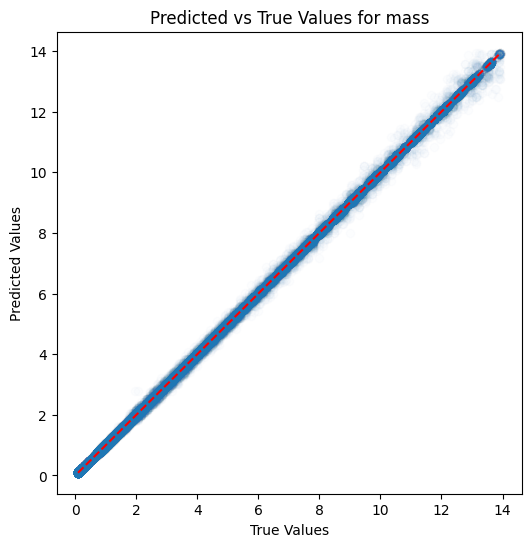

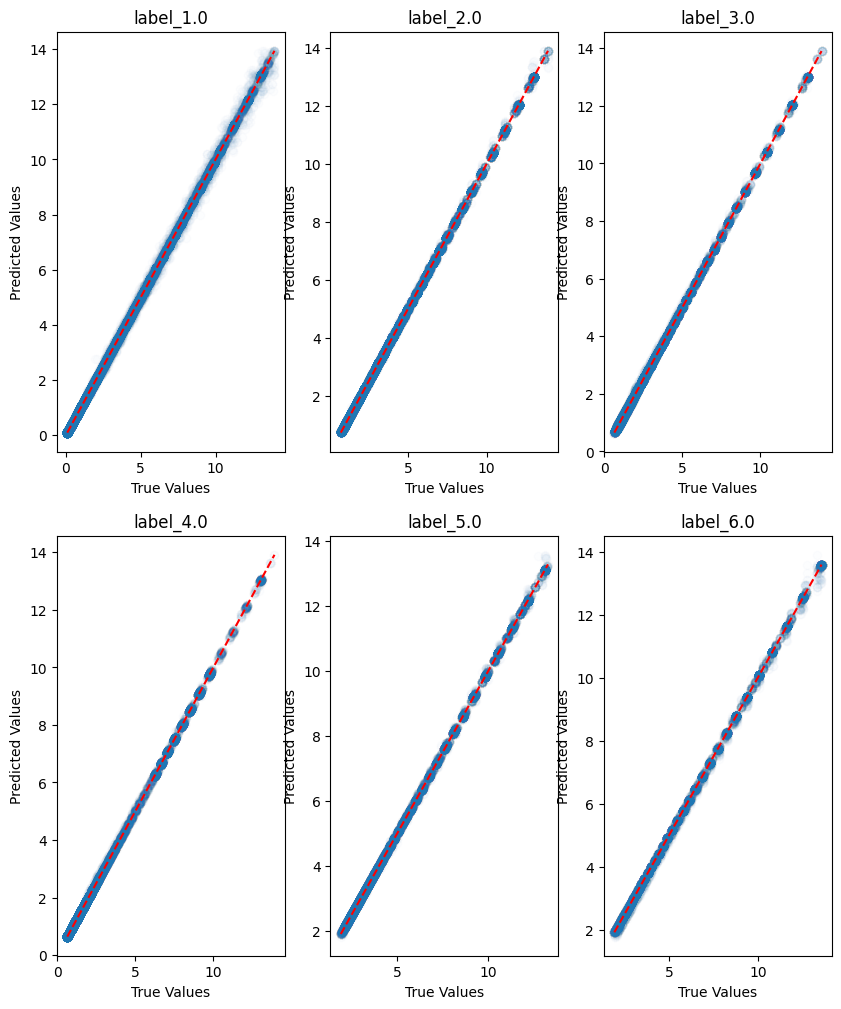

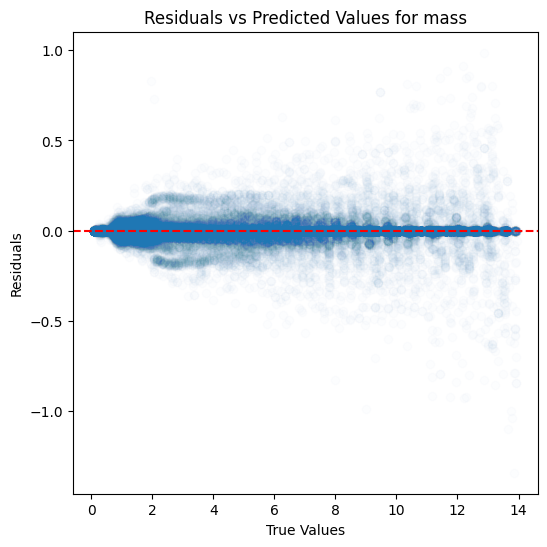

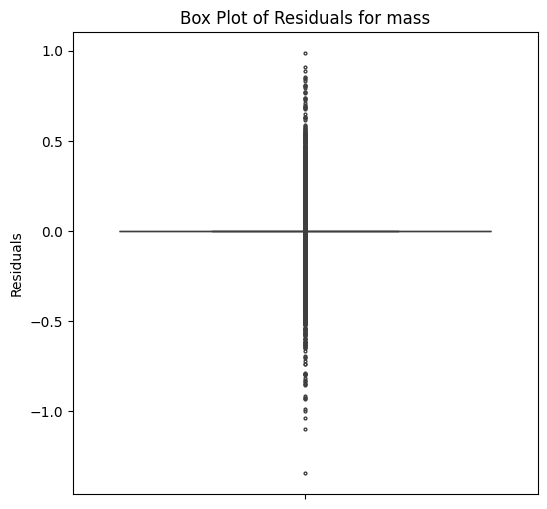

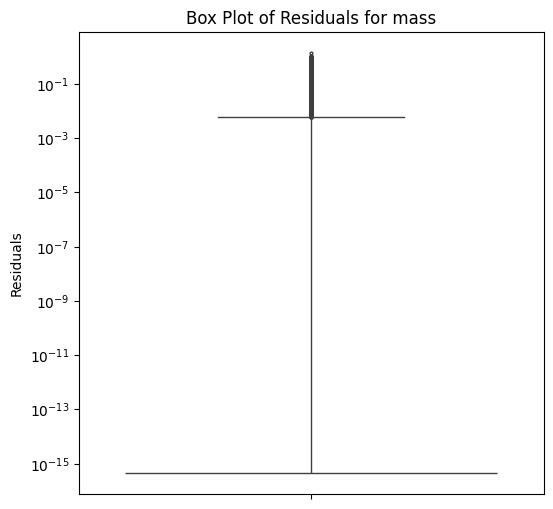

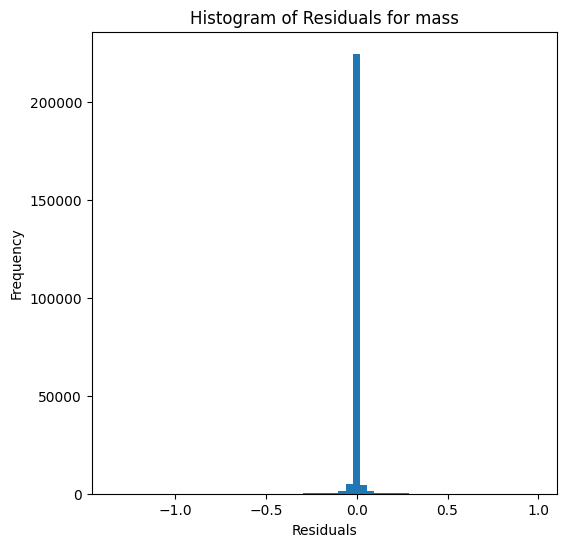

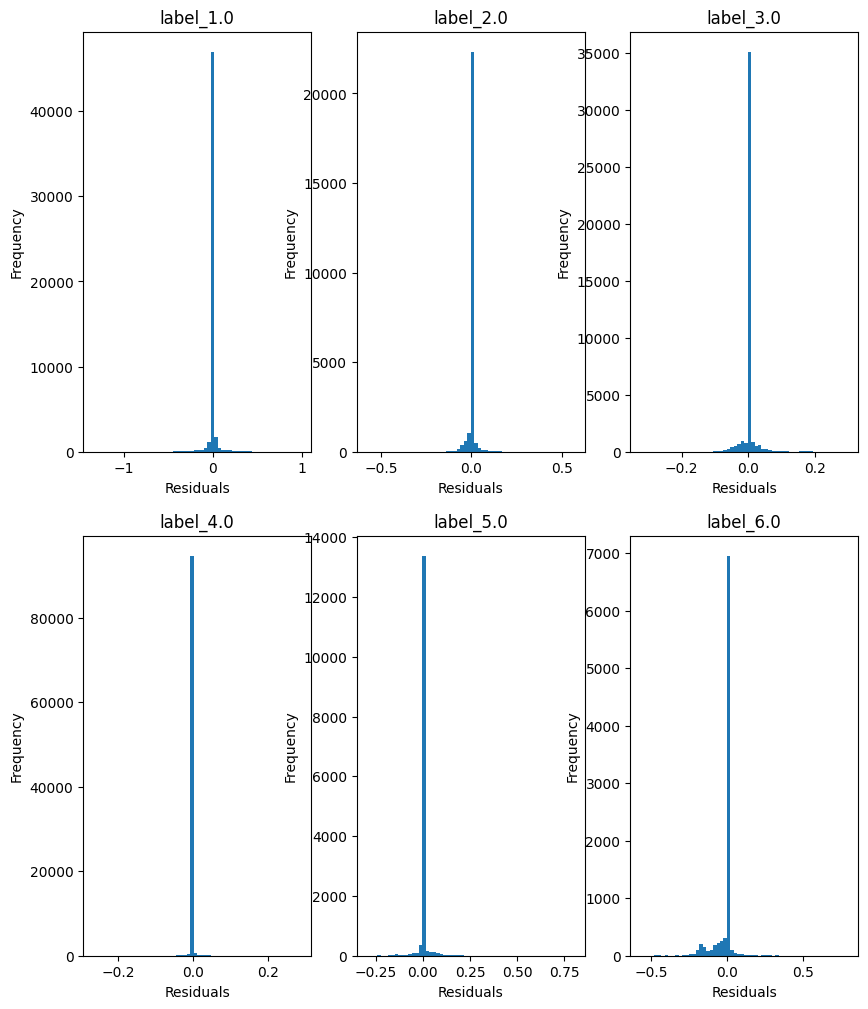

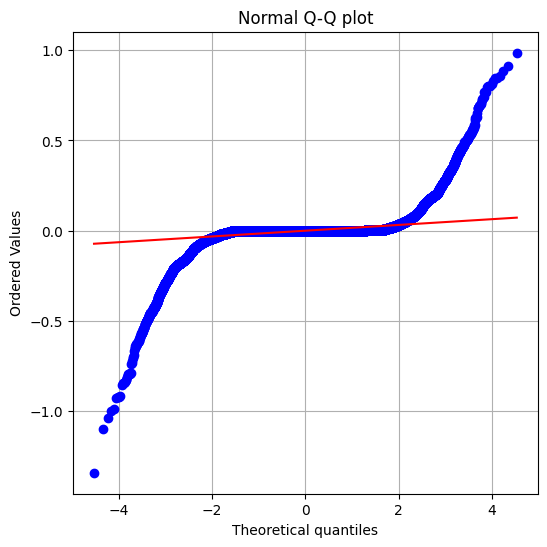

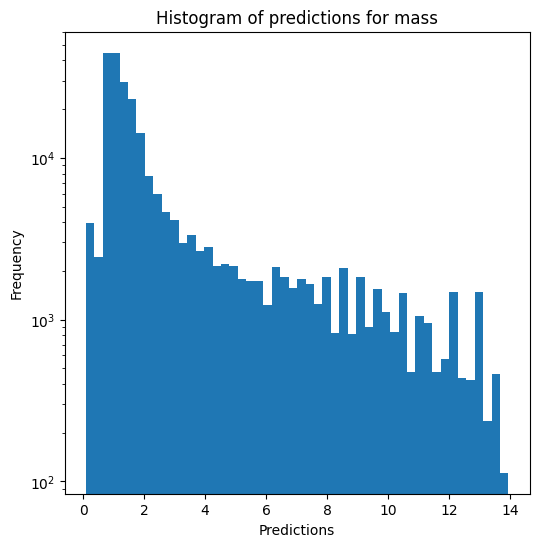

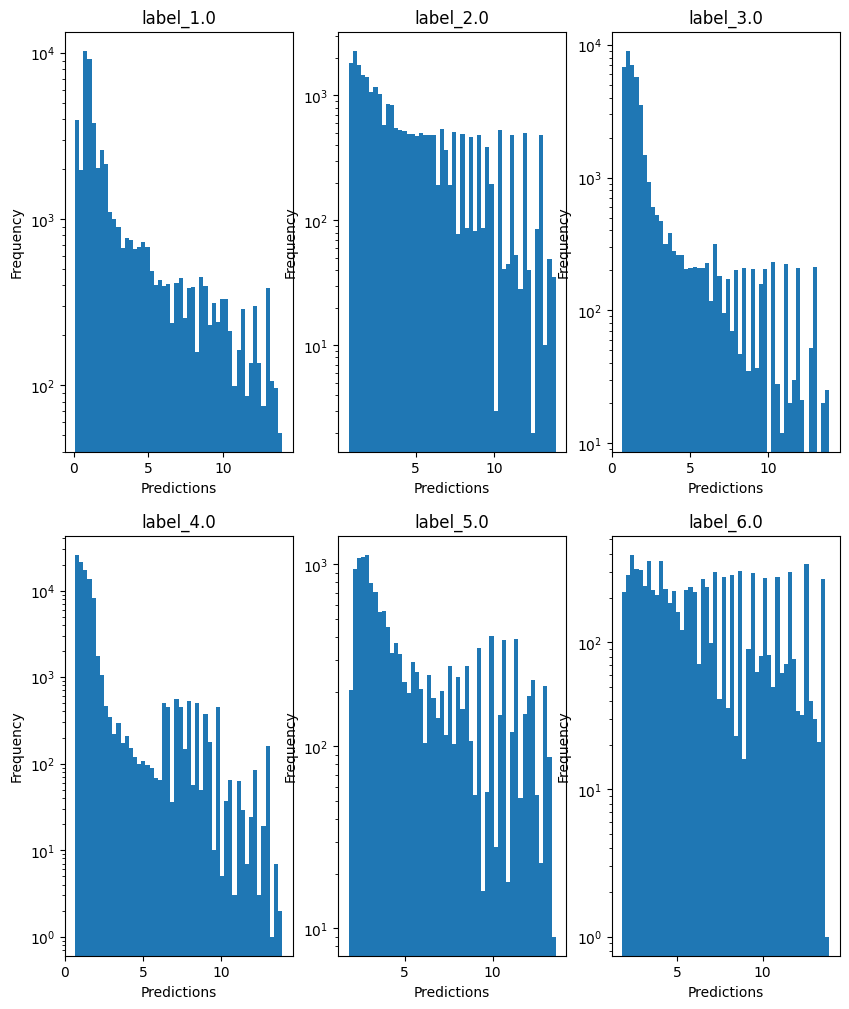

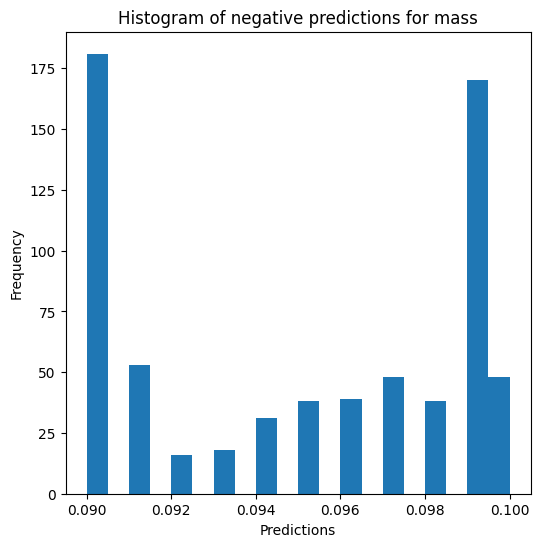

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9996530610796055
  RMSE :  0.0068170223975128124
  MAE :  0.002504717895653694
  MedAE :  2.7755575615628914e-17
  CORR :  0.9998265636626478
  MAX_ER :  0.15067566342895866
  Percentiles : 
    75th percentile :  0.0017307517203548894
    90th percentile :  0.007581485640308944
    95th percentile :  0.013632924999369647
    99th percentile :  0.03191269771220816

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.999286726479723
  RMSE :  0.014459793376539588
  MAE :  0.005549628641896088
  MedAE :  0.0
  CORR :  0.9996474507807832
  MAX_ER :  0.3374512485512551
  Percentiles : 
    75th percentile :  0.006646446420951885
    90th percentile :  0.019420487143368803
    95th percentile :  0.025462985202715158
    99th percentile :  0.04766536047884399

radius results for the label categ

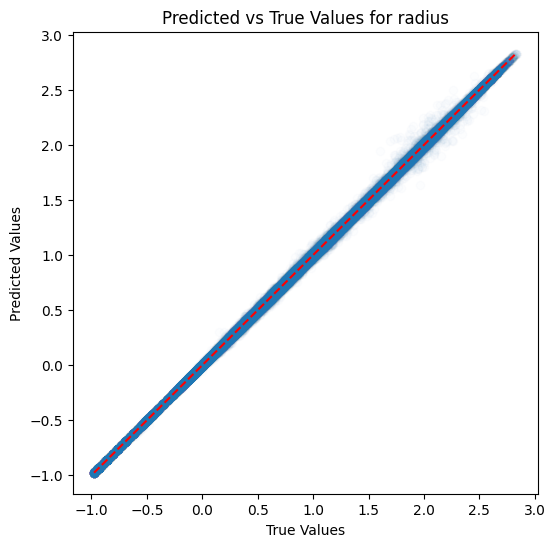

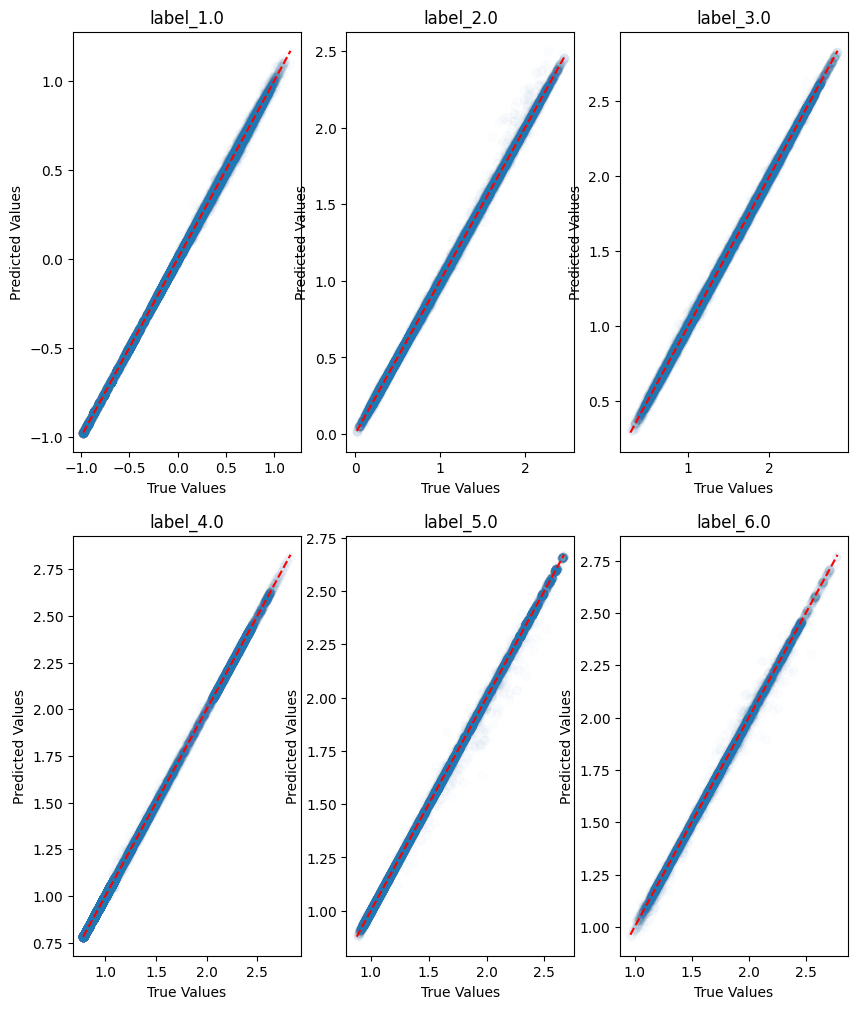

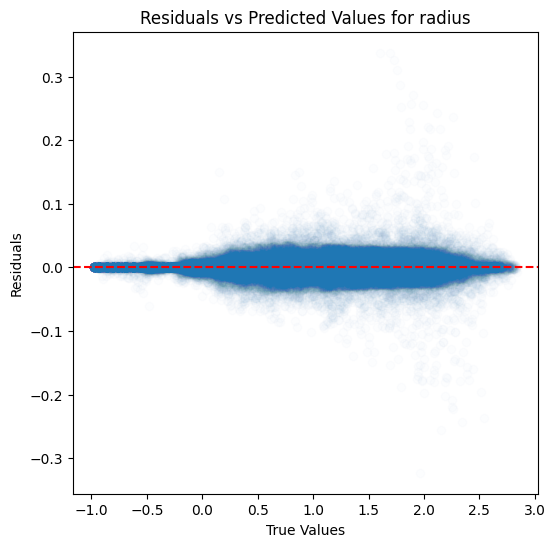

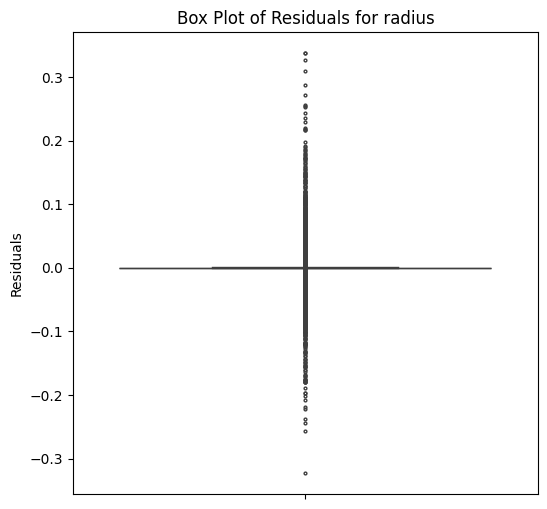

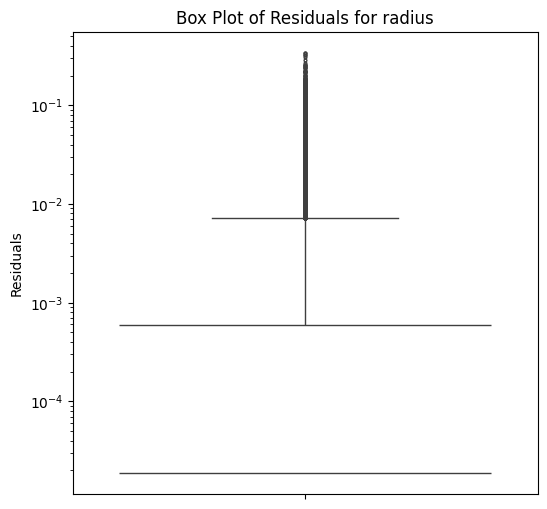

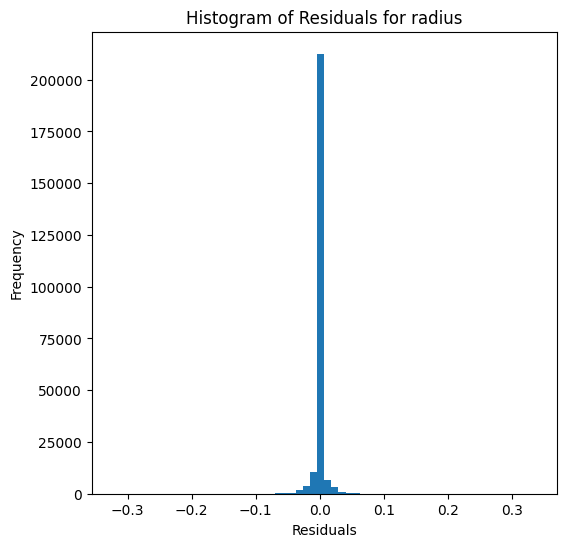

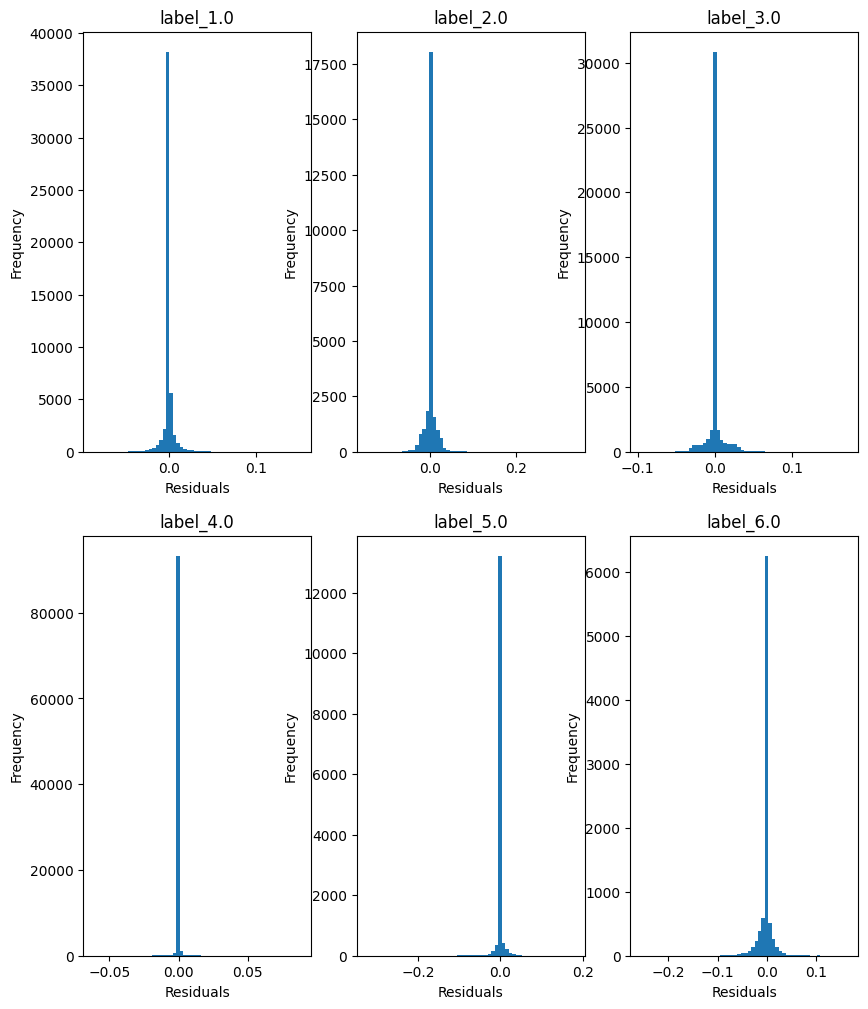

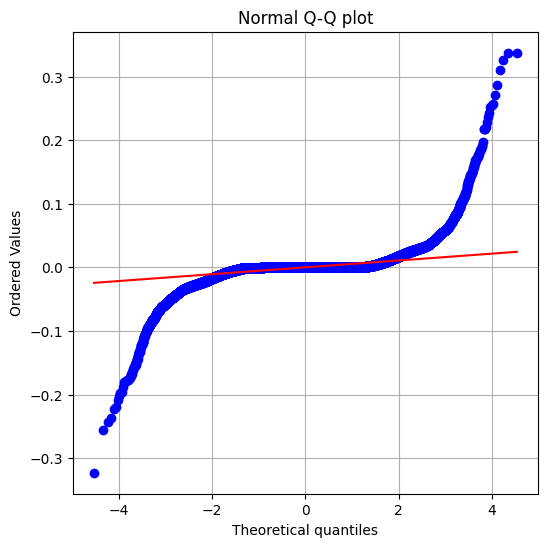

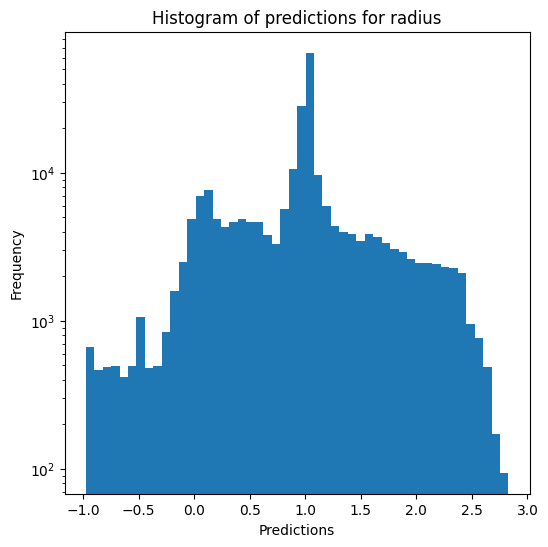

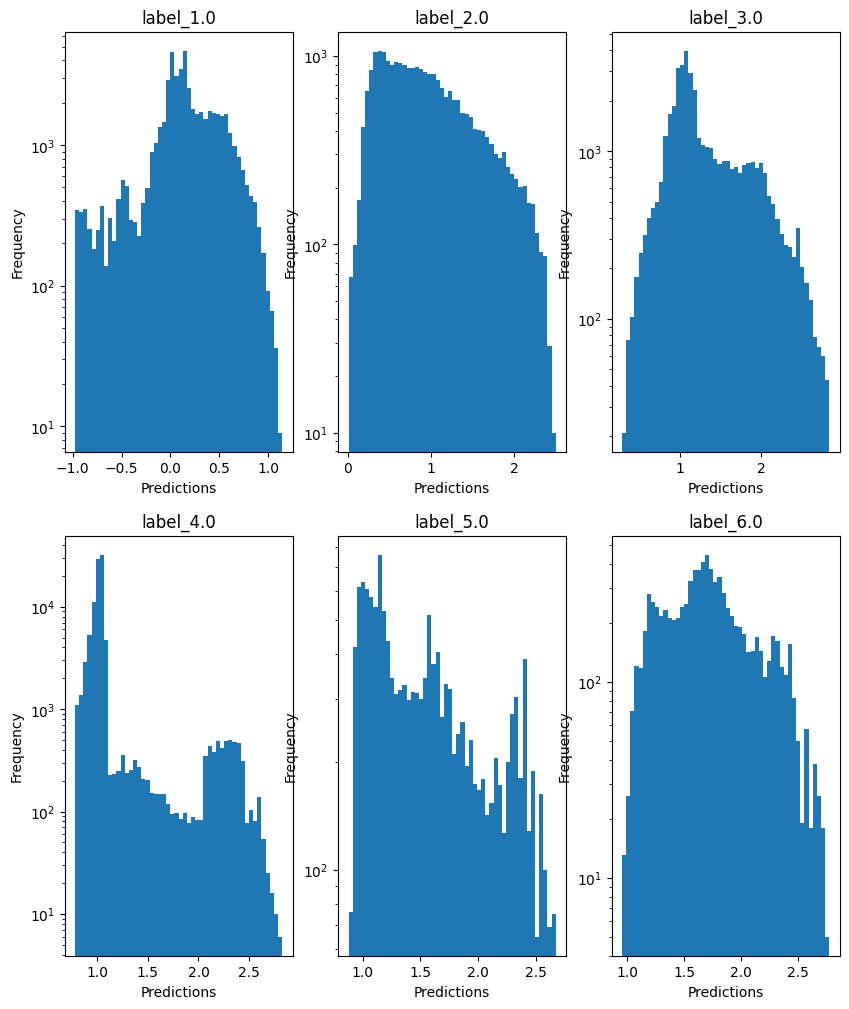

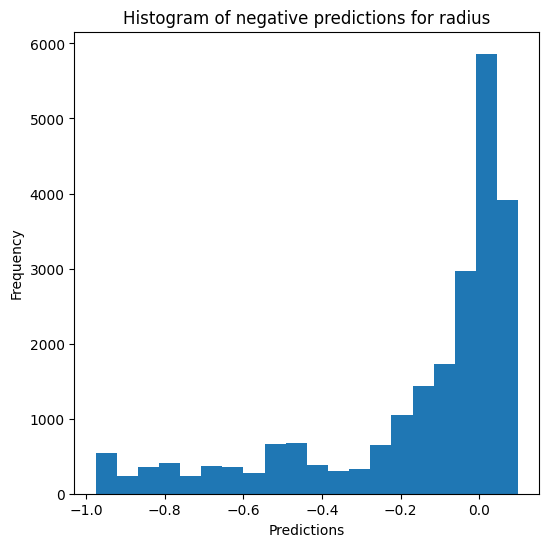

Saving predictions and results...


In [13]:
best_params_DT = {'criterion': 'squared_error', 'splitter': "best", 'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}

print(path_to_results)
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, **best_params_DT)

### Random forest

#### Tuning the n_estimators and criterion parameters

In [18]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [100, 400, 600]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.9s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   6.0s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.6s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.4s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.6s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.6s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.7s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.6s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.4s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=   5.5s
[CV] END ..........criterion=squared_error, n_estimators=400; total time=  21.4s
[CV] END ..........criterion=squared_error, n_es

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,5.590136,0.190545,0.138977,0.011159,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.012989,-0.013161,-0.012280,-0.013708,-0.012980,-0.012076,-0.011929,-0.013104,-0.012476,-0.012362,-0.012707,0.000536,3,-0.003306,-0.003247,-0.003130,-0.003405,-0.003264,-0.003120,-0.003203,-0.003368,-0.003272,-0.003288,-0.003260,0.000087,3
1,22.563002,0.752500,0.503292,0.029900,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.012769,-0.013031,-0.012278,-0.013689,-0.012724,-0.011912,-0.011624,-0.013115,-0.012486,-0.012263,-0.012589,0.000578,1,-0.003252,-0.003205,-0.003071,-0.003361,-0.003212,-0.003070,-0.003128,-0.003328,-0.003241,-0.003226,-0.003209,0.000092,2
2,34.394542,0.481822,0.871594,0.368357,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.012777,-0.013084,-0.012247,-0.013668,-0.012794,-0.011865,-0.011731,-0.013088,-0.012416,-0.012242,-0.012591,0.000571,2,-0.003246,-0.003206,-0.003062,-0.003349,-0.003216,-0.003061,-0.003138,-0.003326,-0.003225,-0.003229,-0.003206,0.000092,1
3,5.978985,0.125658,0.143894,0.017267,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.014665,-0.014823,-0.014086,-0.015295,-0.014511,-0.014189,-0.013980,-0.014824,-0.014455,-0.014395,-0.014522,0.000376,6,-0.003829,-0.003778,-0.003625,-0.003873,-0.003787,-0.003722,-0.003744,-0.003870,-0.003852,-0.003869,-0.003795,0.000077,6
4,22.930330,0.208162,0.489740,0.014676,friedman_mse,400,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.014482,-0.014784,-0.013929,-0.015104,-0.014265,-0.014022,-0.013820,-0.014492,-0.014318,-0.014067,-0.014328,0.000380,4,-0.003744,-0.003741,-0.003581,-0.003840,-0.003711,-0.003673,-0.003687,-0.003780,-0.003799,-0.003806,-0.003736,0.000073,5
5,34.622207,0.462696,0.755369,0.031006,friedman_mse,600,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.014575,-0.014740,-0.013995,-0.014993,-0.014235,-0.013961,-0.013788,-0.014577,-0.014305,-0.014133,-0.014330,0.000363,5,-0.003756,-0.003726,-0.003571,-0.003820,-0.003697,-0.003665,-0.003678,-0.003788,-0.003788,-0.003805,-0.003730,0.000074,4


Best parameters {'criterion': 'squared_error', 'n_estimators': 400}
Best score -0.01258914154102501


#### Tuning the n_estimators parameter further

In [10]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_estimators' : [100, 1000]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 2 candidates, totalling 20 fits
[CV] END ...................................n_estimators=100; total time=  16.1s
[CV] END ...................................n_estimators=100; total time=  15.9s
[CV] END ...................................n_estimators=100; total time=  15.6s
[CV] END ...................................n_estimators=100; total time=  15.5s
[CV] END ...................................n_estimators=100; total time=  15.4s
[CV] END ...................................n_estimators=100; total time=  15.5s
[CV] END ...................................n_estimators=100; total time=  15.4s
[CV] END ...................................n_estimators=100; total time=  15.4s
[CV] END ...................................n_estimators=100; total time=  15.4s
[CV] END ...................................n_estimators=100; total time=  15.6s
[CV] END ..................................n_estimators=1000; total time= 3.7min
[CV] END ..................................n_est

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,15.413757,0.224142,0.260015,0.025585,100,{'n_estimators': 100},-0.018124,-0.018388,-0.018987,-0.018112,-0.019537,-0.018479,-0.018965,-0.018299,-0.018838,-0.018357,-0.018609,0.000435,2,-0.006973,-0.006932,-0.007010,-0.006761,-0.007123,-0.006883,-0.006840,-0.006909,-0.006876,-0.006987,-0.006929,0.000095,2
1,166.531170,26.808580,97.407573,8.695572,1000,{'n_estimators': 1000},-0.017897,-0.018315,-0.018702,-0.017952,-0.019303,-0.018122,-0.018849,-0.018173,-0.018614,-0.018211,-0.018414,0.000422,1,-0.006818,-0.006821,-0.006856,-0.006647,-0.006933,-0.006751,-0.006709,-0.006810,-0.006729,-0.006831,-0.006791,0.000078,1


Best parameters {'n_estimators': 1000}
Best score -0.018413790633118023


More estimators always gives better results, but the more you add, the less return there is

#### Tuning the max_depth, min_samples_split and min_samples_leaf parameters

In [19]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="squared_error",
                                             n_estimators=100, # results with more estimators are better but take more time, doing gridsearchcv with 100 is comparable to more
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.9s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.8s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.8s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   5.9s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=   6.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=   5.2s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,5.930659,0.120364,0.135977,0.011122,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.012825,-0.013074,-0.012473,-0.013847,-0.012992,-0.012088,-0.011827,-0.013547,-0.012711,-0.012475,-0.012786,0.000586,3,-0.003295,-0.003238,-0.003140,-0.003405,-0.003277,-0.003120,-0.003201,-0.003411,-0.003312,-0.003297,-0.003270,0.000093,3
1,5.252181,0.062533,0.104130,0.006899,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.014200,-0.014384,-0.013690,-0.014769,-0.014371,-0.013536,-0.013108,-0.014493,-0.014106,-0.013799,-0.014046,0.000479,5,-0.003962,-0.003899,-0.003776,-0.004012,-0.003947,-0.003775,-0.003837,-0.004012,-0.003975,-0.003946,-0.003914,0.000085,4
2,4.994057,0.111537,0.097034,0.022501,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.016507,-0.016638,-0.016058,-0.016982,-0.016667,-0.015408,-0.015540,-0.016614,-0.016297,-0.016112,-0.016282,0.000482,14,-0.005145,-0.005063,-0.004988,-0.005210,-0.005196,-0.004934,-0.005041,-0.005184,-0.005114,-0.005137,-0.005101,0.000088,15
3,5.134768,0.103095,0.105563,0.013375,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.015485,-0.015716,-0.015031,-0.016184,-0.015605,-0.014672,-0.014266,-0.015910,-0.015378,-0.014652,-0.015290,0.000584,11,-0.004666,-0.004617,-0.004465,-0.004742,-0.004695,-0.004460,-0.004494,-0.004720,-0.004679,-0.004607,-0.004615,0.000101,10
4,5.152818,0.087488,0.099572,0.007451,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.015416,-0.015605,-0.014961,-0.016124,-0.015747,-0.014466,-0.014451,-0.015664,-0.015424,-0.014632,-0.015249,0.000555,8,-0.004648,-0.004609,-0.004446,-0.004719,-0.004709,-0.004433,-0.004521,-0.004678,-0.004708,-0.004600,-0.004607,0.000102,8
5,4.960417,0.069351,0.091862,0.013750,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.017214,-0.017314,-0.016539,-0.017950,-0.017735,-0.016266,-0.016237,-0.017264,-0.016975,-0.016557,-0.017005,0.000564,17,-0.005470,-0.005406,-0.005275,-0.005561,-0.005600,-0.005249,-0.005359,-0.005510,-0.005467,-0.005385,-0.005428,0.000109,17
6,4.798566,0.068627,0.087582,0.017321,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.018756,-0.018690,-0.018132,-0.019433,-0.019237,-0.017466,-0.017644,-0.018358,-0.018549,-0.017614,-0.018388,0.000643,26,-0.006164,-0.006070,-0.005960,-0.006277,-0.006285,-0.005929,-0.006048,-0.006137,-0.006141,-0.006067,-0.006108,0.000112,22
7,4.809110,0.046126,0.088385,0.019124,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.018592,-0.018736,-0.017767,-0.019268,-0.018984,-0.017612,-0.017538,-0.018541,-0.018541,-0.017792,-0.018337,0.000581,24,-0.006181,-0.006086,-0.005938,-0.006244,-0.006288,-0.005969,-0.006043,-0.006165,-0.006164,-0.006080,-0.006116,0.000108,25
8,4.819741,0.063922,0.079350,0.003921,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.018569,-0.018473,-0.018004,-0.019086,-0.019074,-0.017527,-0.017570,-0.01

Best parameters {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -0.012762850931382932


#### Tuning the max_features and max_leaf_nodes parameters

In [20]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [50, 100, 200, None]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="squared_error",
                                             n_estimators=100,
                                             max_depth=None,
                                             min_samples_leaf=1,
                                             min_samples_split=2
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.6s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   1.5s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   1.6s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,1.560961,0.044784,0.031479,0.008302,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-0.156524,-0.160473,-0.159057,-0.158778,-0.160858,-0.156658,-0.160279,-0.162369,-0.157202,-0.159144,-0.159134,0.001826,11,-0.100485,-0.103826,-0.103981,-0.103674,-0.105228,-0.102285,-0.103891,-0.104581,-0.101732,-0.102937,-0.103262,0.001346,11
1,1.700987,0.029739,0.034860,0.011293,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.106440,-0.108131,-0.106176,-0.107613,-0.105466,-0.104612,-0.106364,-0.106997,-0.104619,-0.107424,-0.106384,0.001147,8,-0.068544,-0.069643,-0.068754,-0.070309,-0.068738,-0.068483,-0.069001,-0.069792,-0.068594,-0.070233,-0.069209,0.000679,7
2,1.860397,0.035110,0.031820,0.004930,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-0.074161,-0.073632,-0.072778,-0.073327,-0.074164,-0.071451,-0.073142,-0.072210,-0.072694,-0.074040,-0.073160,0.000850,5,-0.046645,-0.046562,-0.046140,-0.046679,-0.047385,-0.046210,-0.046879,-0.046367,-0.046731,-0.047216,-0.046681,0.000381,5
3,3.470740,0.073961,0.130133,0.007172,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.012062,-0.013416,-0.012236,-0.012853,-0.012196,-0.011628,-0.011452,-0.012524,-0.011493,-0.012020,-0.012188,0.000587,2,-0.003408,-0.003556,-0.003404,-0.003541,-0.003418,-0.003360,-0.003379,-0.003490,-0.003399,-0.003512,-0.003447,0.000067,3
4,1.533426,0.057829,0.029103,0.007140,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-0.157816,-0.159349,-0.160698,-0.158179,-0.159101,-0.155660,-0.160618,-0.159387,-0.157230,-0.162891,-0.159093,0.001929,10,-0.101559,-0.101572,-0.104757,-0.102641,-0.104188,-0.100454,-0.103112,-0.102948,-0.101827,-0.105060,-0.102812,0.001432,10
5,1.679571,0.023925,0.031497,0.010685,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.107366,-0.108414,-0.105350,-0.106026,-0.107199,-0.105509,-0.104833,-0.106946,-0.103817,-0.107321,-0.106278,0.001334,7,-0.069086,-0.070446,-0.068945,-0.069253,-0.069749,-0.069166,-0.068191,-0.070142,-0.068015,-0.069918,-0.069291,0.000753,8
6,1.873270,0.040359,0.036990,0.013856,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-0.072885,-0.074173,-0.072455,-0.072077,-0.072287,-0.070893,-0.072649,-0.072770,-0.071330,-0.073728,-0.072525,0.000934,4,-0.046483,-0.046747,-0.046408,-0.046261,-0.046493,-0.045753,-0.046873,-0.047073,-0.045661,-0.046874,-0.046463,0.000445,4
7,3.493229,0.055941,0.141482,0.016581,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.012330,-0.013268,-0.012064,-0.012646,-0.012081,-0.011645,-0.010921,-0.012434,-0.011502,-0.011931,-0.012082,0.000617,1,-0.003432,-0.003494,-0.003338,-0.003491,-0.003399,-0.003382,-0.003276,-0.003468,-0.003417,-0.003505,-0.003420,0.000070,2
8,2.421933,0.041129,0.032762,0.008326,None,50,"{'max_features': None, 'max_leaf_nodes': 50}",-0.196409,-0.197731,-0.197757,-0.198858,-0.204007,-0.198895,-0.200083,-0.200415,-0.197027,-0.196615,-0.198780,0

Best parameters {'max_features': 'log2', 'max_leaf_nodes': None}
Best score -0.012082280433075363


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9998873520698947
  RMSE :  0.03202809354967581
  MAE :  0.00843412659771191
  MedAE :  0.0002650000000010144
  CORR :  0.9999436945446284
  MAX_ER :  0.778904000000038
  Percentiles : 
    75th percentile :  0.00306675000000467
    90th percentile :  0.018733499999995296
    95th percentile :  0.042914000000124686
    99th percentile :  0.14900760000003196

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999730750584974
  RMSE :  0.017411327733360918
  MAE :  0.006808731905349863
  MedAE :  0.0006120000000922055
  CORR :  0.9999866009146333
  MAX_ER :  0.4971840000000327
  Percentiles : 
    75th percentile :  0.0065165000000252105
    90th percentile :  0.021373500000056552

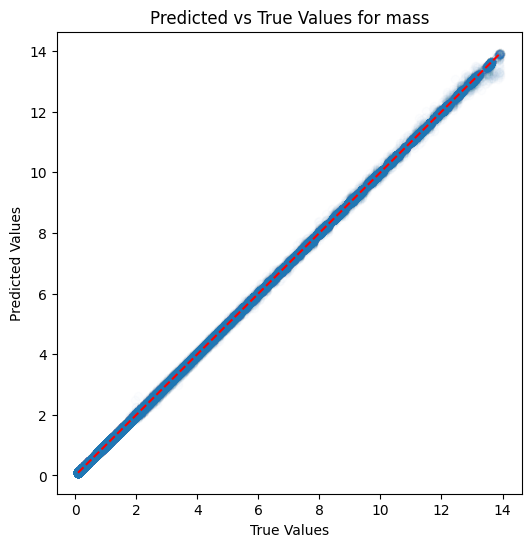

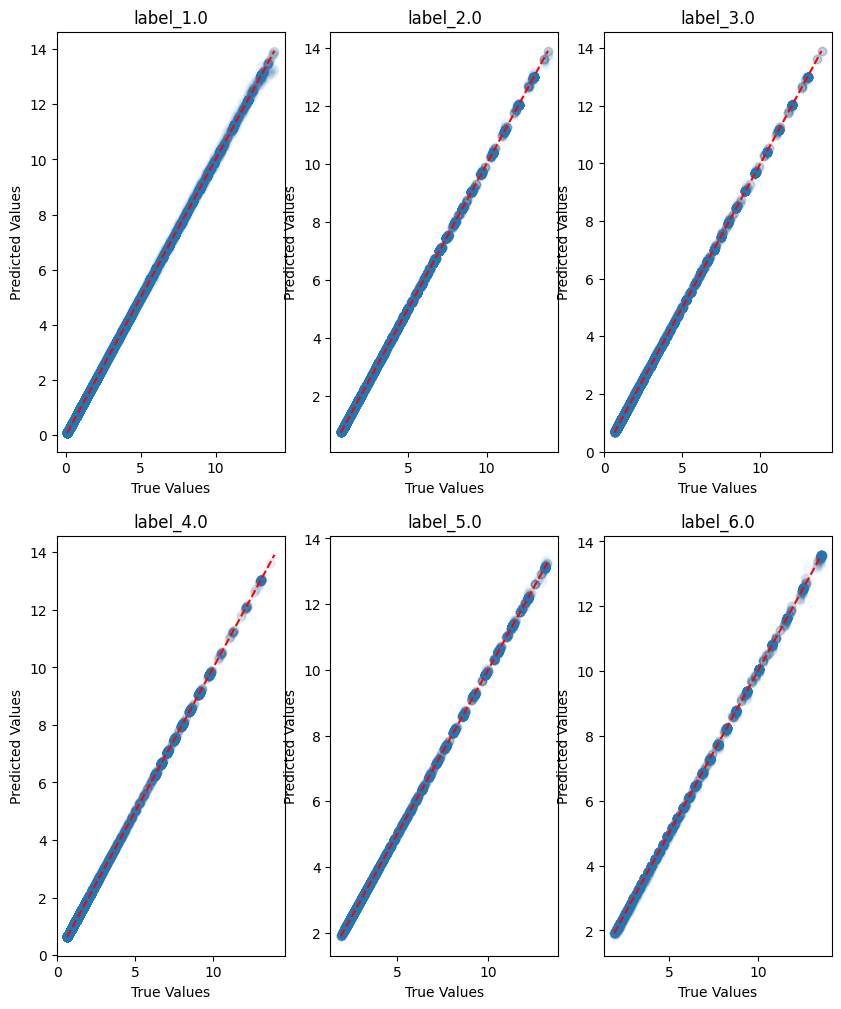

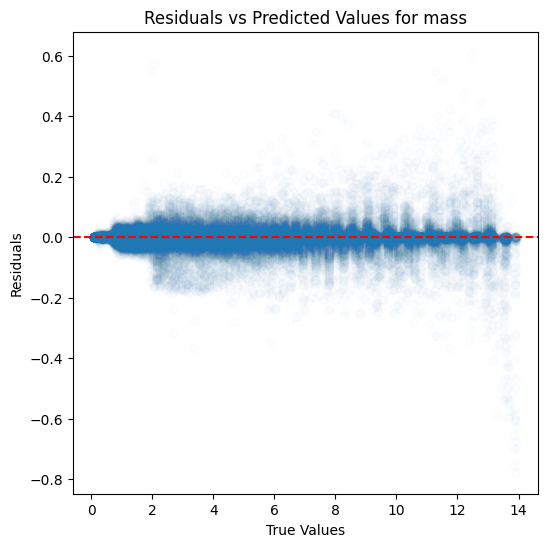

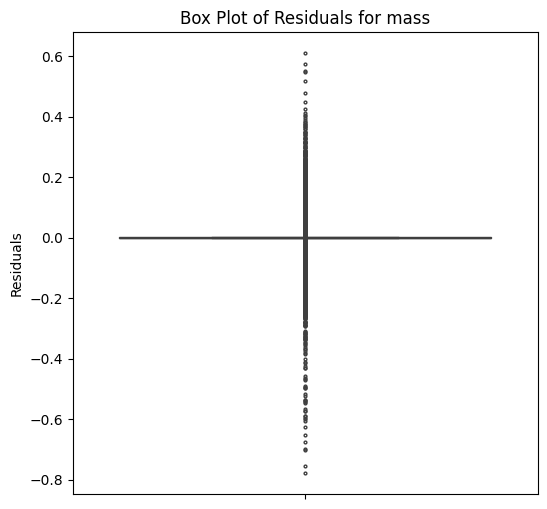

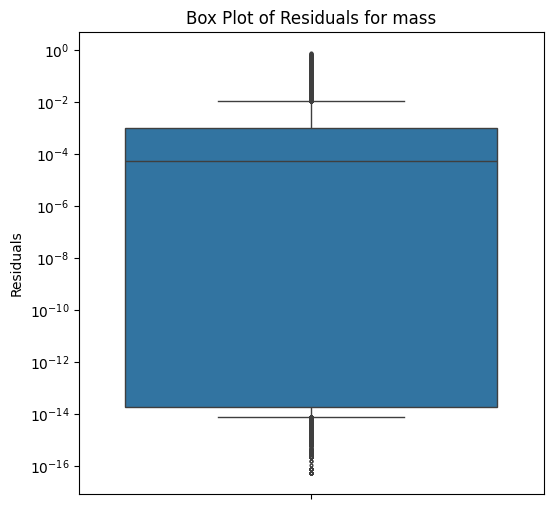

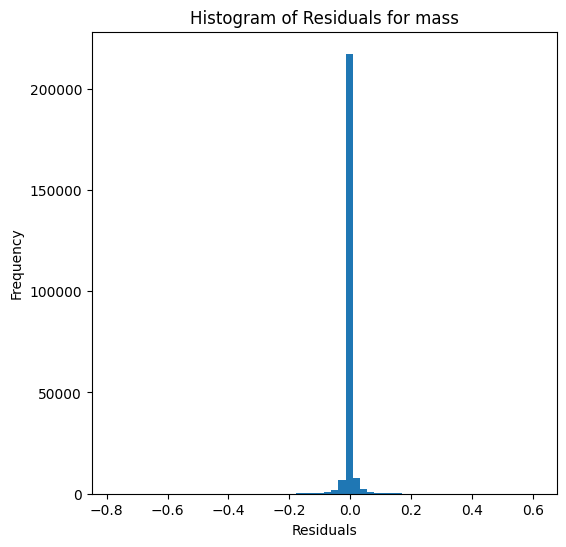

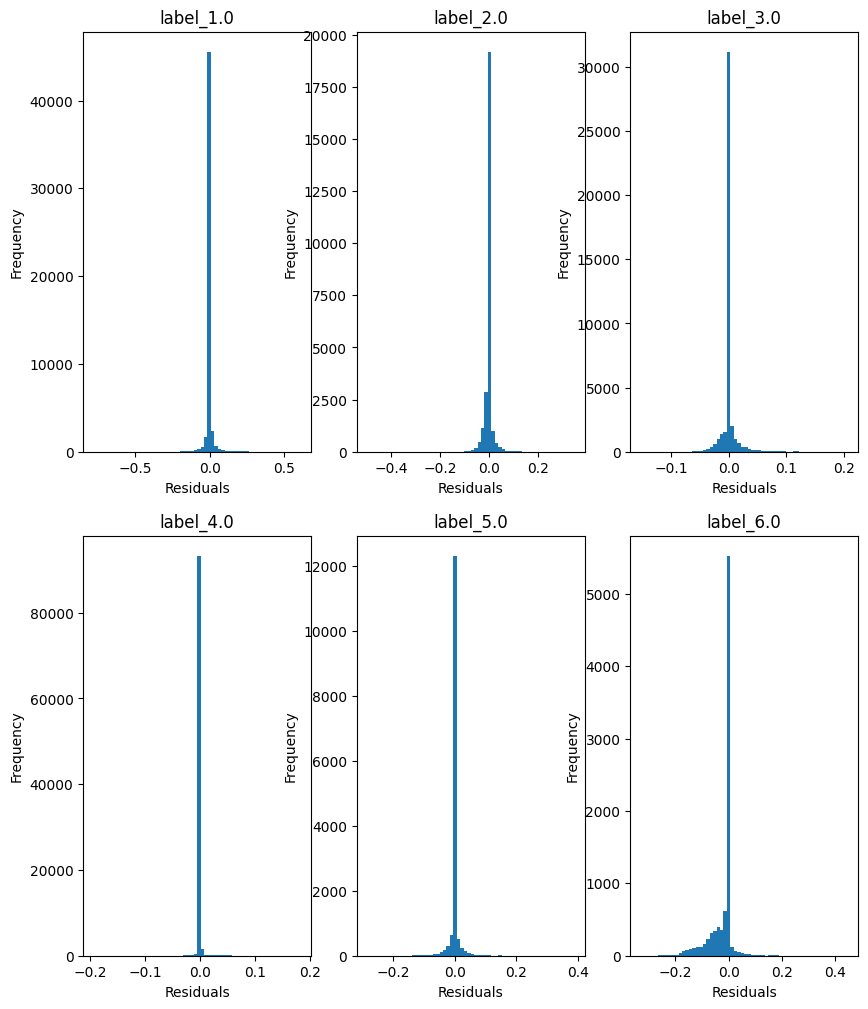

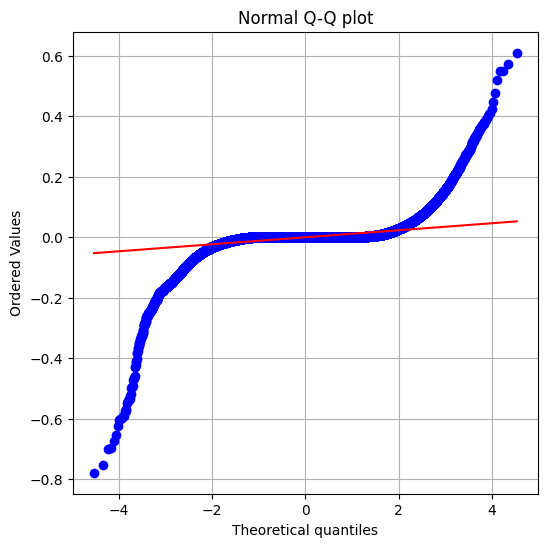

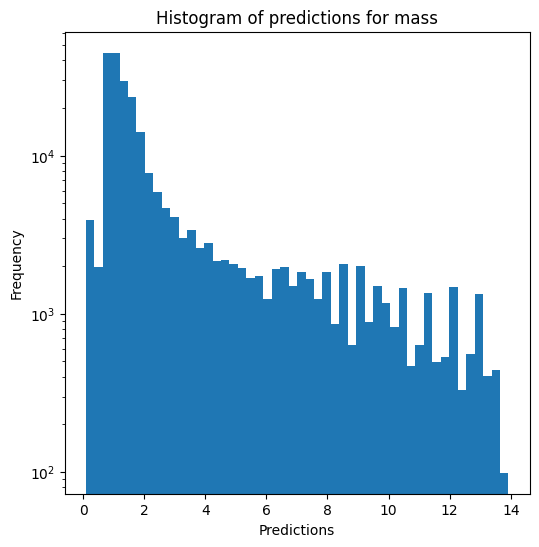

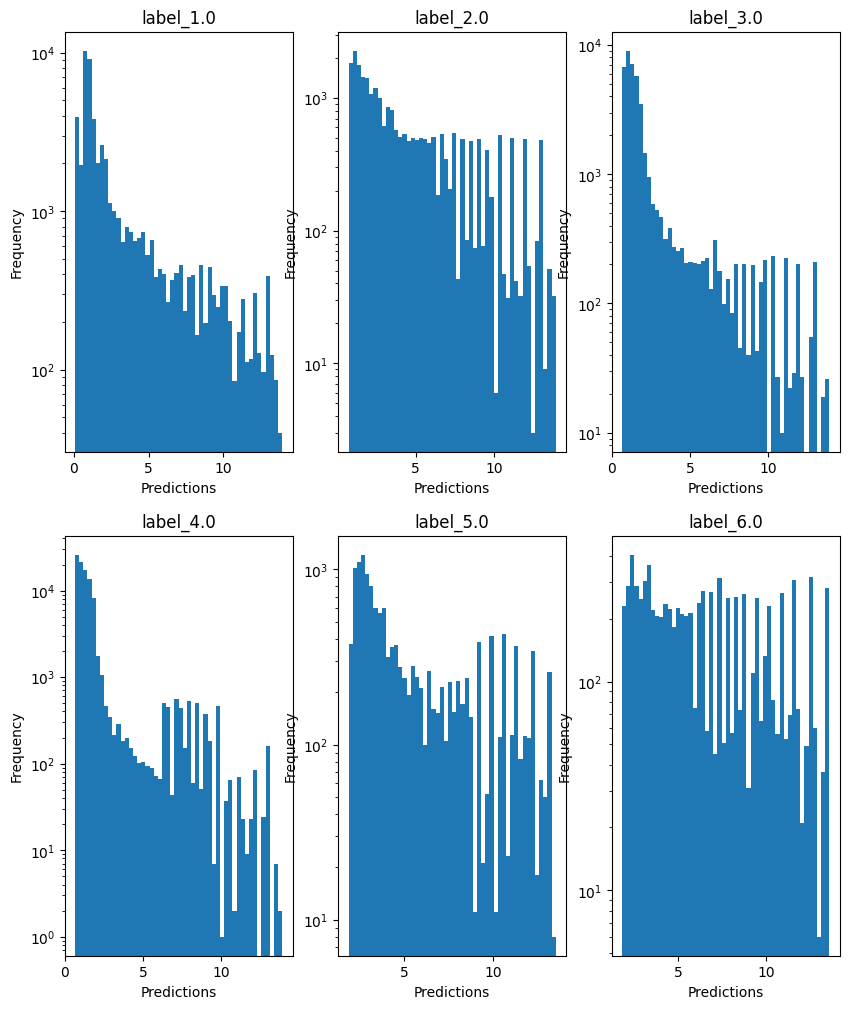

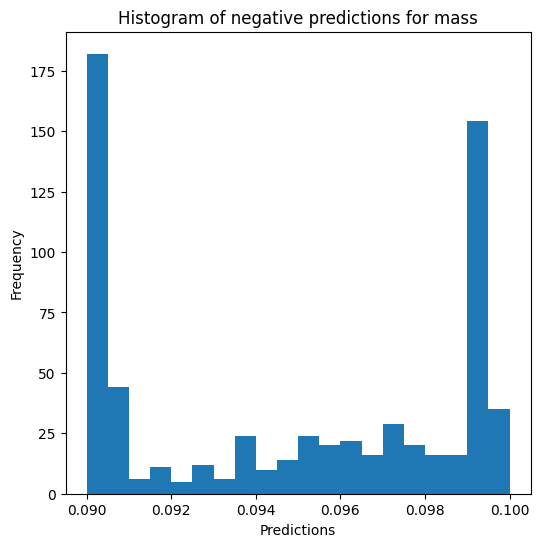


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9999231539912501
  RMSE :  0.003208200639217283
  MAE :  0.0012617100858316307
  MedAE :  0.00014876587311549172
  CORR :  0.9999616535553641
  MAX_ER :  0.07351213618116276
  Percentiles : 
    75th percentile :  0.0010342361573680552
    90th percentile :  0.003809099654312517
    95th percentile :  0.006479424054333882
    99th percentile :  0.014193771303553215

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9997721594223666
  RMSE :  0.00820009752068843
  MAE :  0.0027096997766529415
  MedAE :  0.0003371356540970427
  CORR :  0.9998905062173411
  MAX_ER :  0.26961863094131444
  Percentiles : 
    75th percentile :  0.0025935202492876064
    90th percentile :  0.007486564062062539
    95th percentile :  0.011625919005673297
    99th percentile :  0.028067351203530745

radius resu

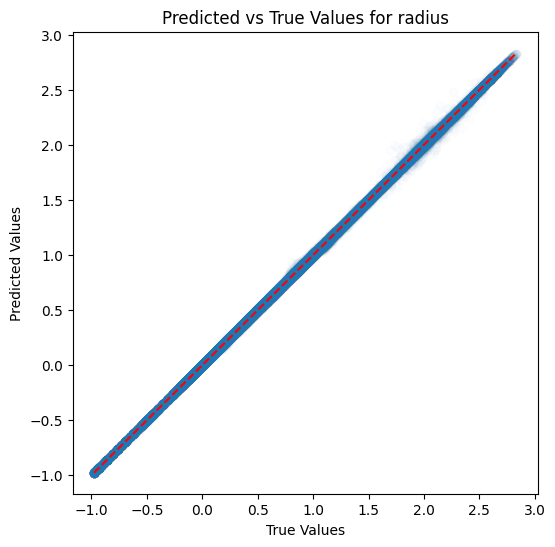

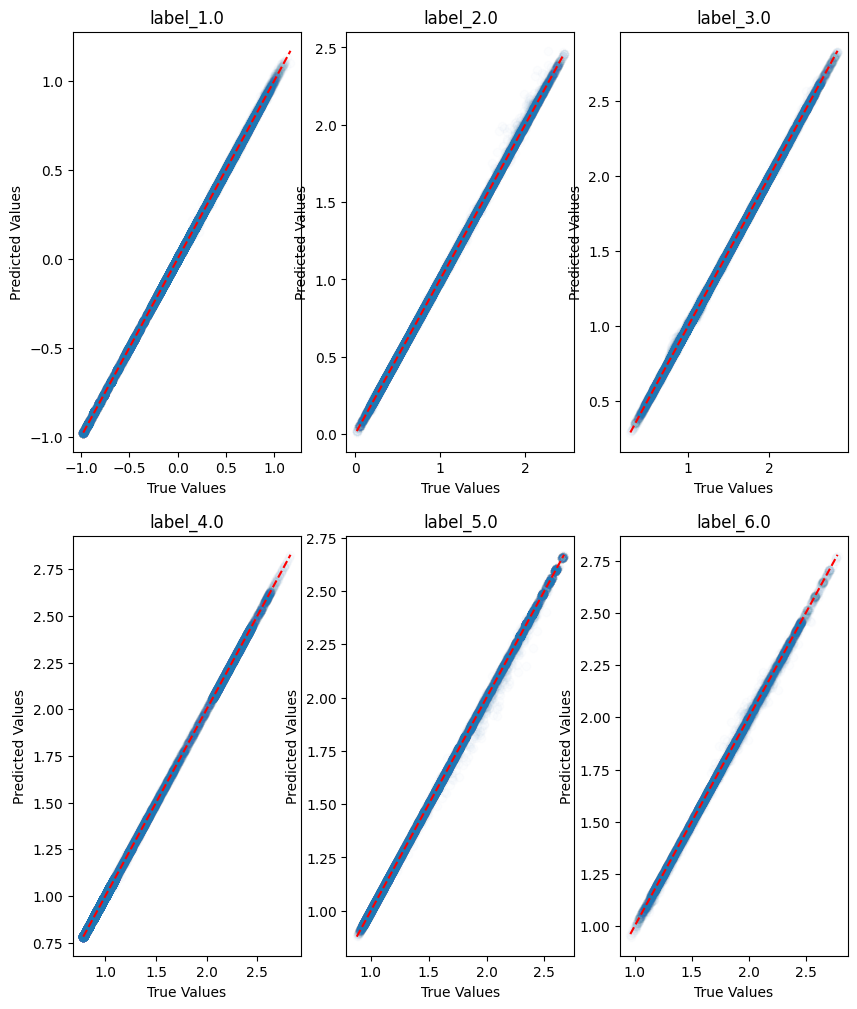

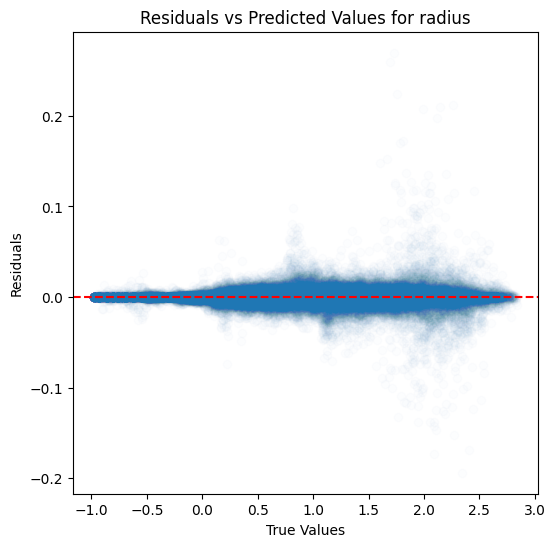

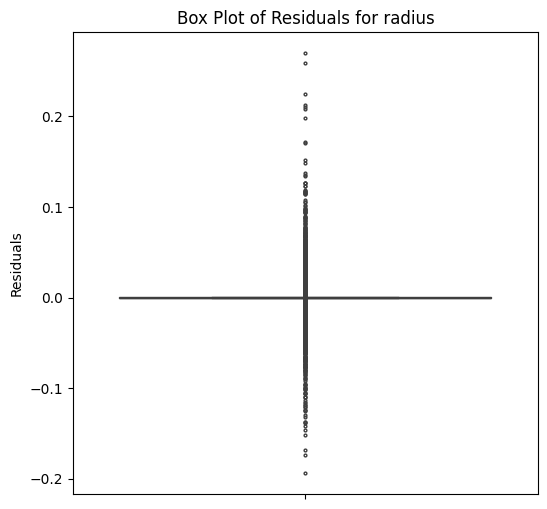

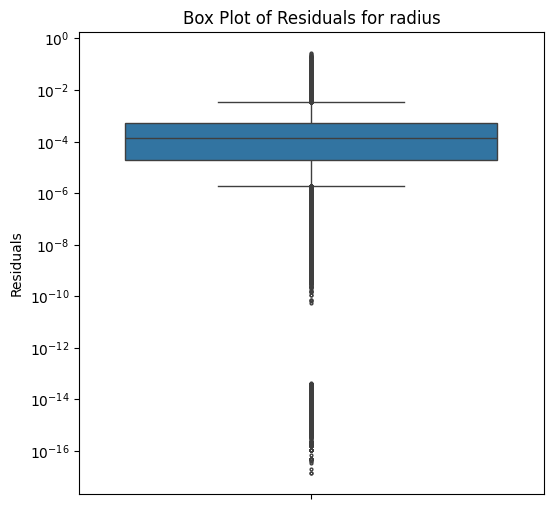

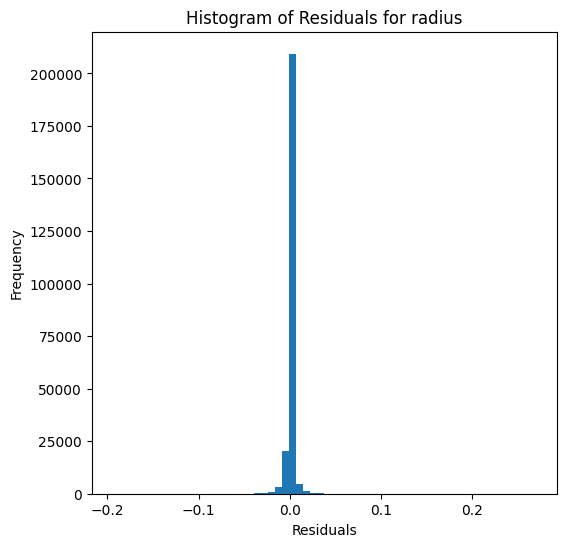

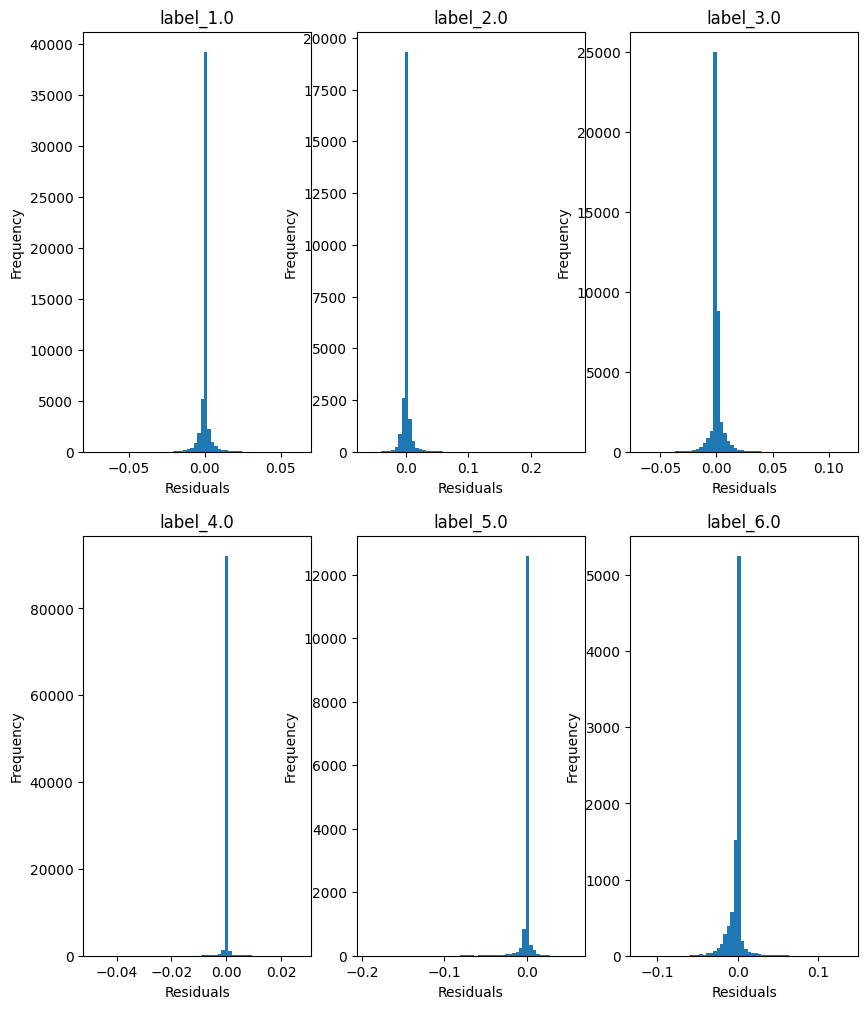

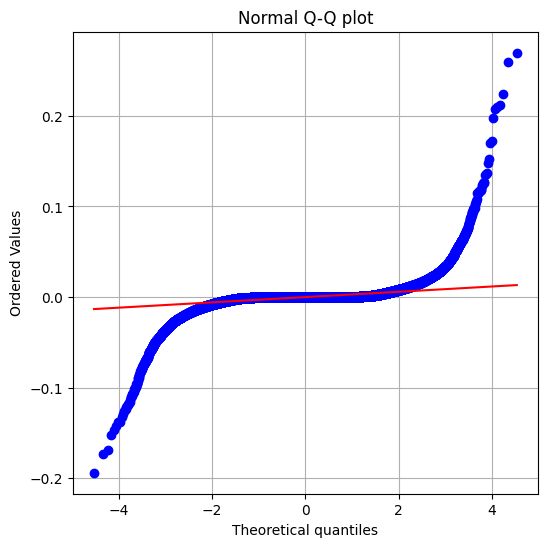

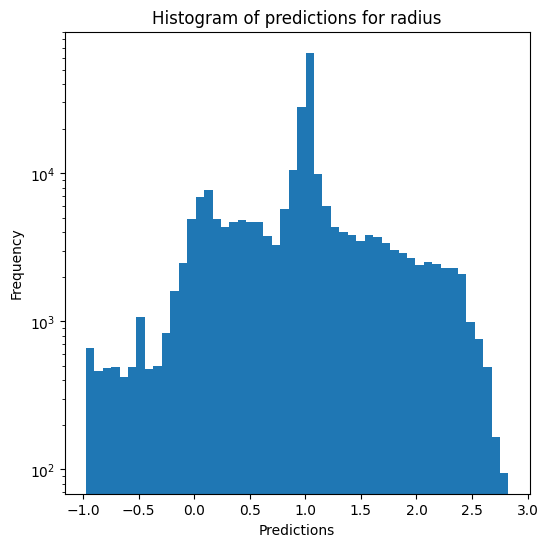

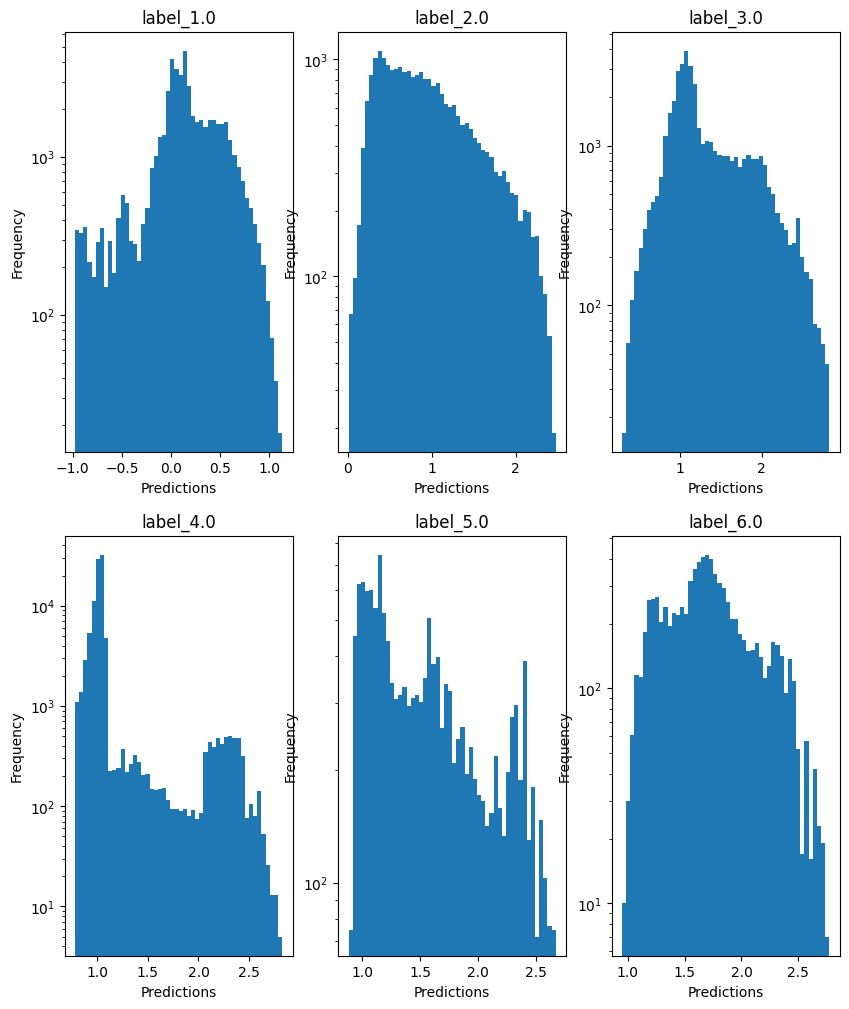

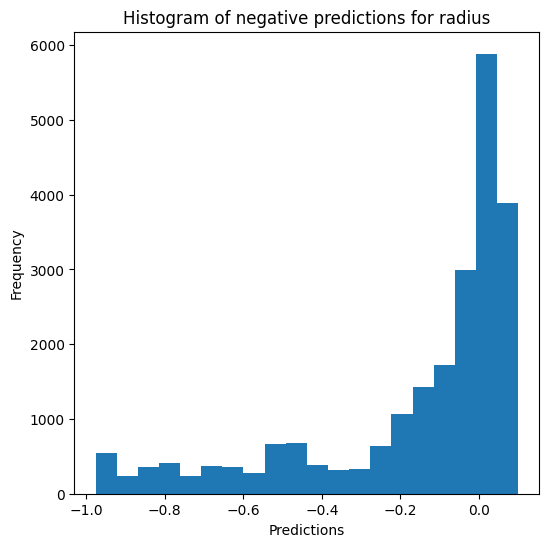

Saving predictions and results...


In [ ]:
best_params_RF = {'n_jobs':10, 'n_estimators': 1000, 'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}
# après quelques tests, 'max_features" = None donne de meilleurs résultats que 'sqrt' et 'log2'

print(path_to_results)
dt_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, **best_params_RF)

### K nearest neighbours

#### Testing the uniform weights with brute strength

In [14]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_rf = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   1.7s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.007981,0.001137,2.037339,0.517132,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-0.051563,-0.059601,-0.054682,-0.050877,-0.053284,-0.052519,-0.053572,-0.050999,-0.049686,-0.053513,-0.053030,0.002624,1,-0.016254,-0.016548,-0.016614,-0.016188,-0.016519,-0.016281,-0.016267,-0.016111,-0.015885,-0.016684,-0.016335,0.000238,1
1,0.008056,0.000481,1.796174,0.023111,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-0.063561,-0.069876,-0.069018,-0.064120,-0.065061,-0.064249,-0.066588,-0.063961,-0.062496,-0.065377,-0.065431,0.002269,2,-0.017835,-0.018211,-0.018508,-0.017920,-0.017987,-0.017837,-0.017914,-0.017970,-0.017535,-0.018114,-0.017983,0.000244,2
2,0.007854,0.000827,1.827100,0.040973,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-0.085100,-0.087490,-0.090430,-0.084918,-0.086816,-0.083738,-0.086974,-0.085154,-0.081008,-0.086044,-0.085767,0.002359,3,-0.023603,-0.023883,-0.024540,-0.023771,-0.024378,-0.023494,-0.023843,-0.023963,-0.023223,-0.023947,-0.023865,0.000369,3
3,0.007251,0.000526,1.855120,0.042621,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-0.102032,-0.102991,-0.105731,-0.102792,-0.103871,-0.100239,-0.103679,-0.101279,-0.097250,-0.102899,-0.102276,0.002193,4,-0.028384,-0.028956,-0.029415,-0.028657,-0.029626,-0.028503,-0.028715,-0.028921,-0.027986,-0.028801,-0.028797,0.000453,4
4,0.007130,0.001038,1.888021,0.029519,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-0.125784,-0.127958,-0.128747,-0.126200,-0.129357,-0.126009,-0.125849,-0.124569,-0.121352,-0.126134,-0.126196,0.002146,5,-0.037284,-0.038540,-0.038674,-0.037744,-0.039228,-0.037980,-0.037531,-0.038010,-0.036942,-0.037824,-0.037976,0.000648,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}
Best score -0.05302968962614908


#### Testing the uniform weights with algorithms

In [15]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_rf = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.169438,0.018178,0.945048,0.070320,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.051563,-0.059590,-0.054681,-0.050878,-0.053286,-0.052513,-0.053572,-0.050998,-0.049679,-0.053518,-0.053028,0.002622,5,-0.016254,-0.016541,-0.016613,-0.016191,-0.016521,-0.016279,-0.016266,-0.016111,-0.015882,-0.016682,-0.016334,0.000238,8
1,0.165659,0.013035,1.149602,0.038405,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.063560,-0.069876,-0.069017,-0.064119,-0.065061,-0.064249,-0.066589,-0.063961,-0.062499,-0.065375,-0.065431,0.002269,20,-0.017833,-0.018212,-0.018507,-0.017920,-0.017987,-0.017837,-0.017916,-0.017968,-0.017536,-0.018114,-0.017983,0.000244,20
2,0.140914,0.009419,1.272829,0.046546,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.085100,-0.087491,-0.090430,-0.084918,-0.086816,-0.083739,-0.086974,-0.085154,-0.081008,-0.086044,-0.085767,0.002359,23,-0.023603,-0.023885,-0.024540,-0.023772,-0.024378,-0.023494,-0.023843,-0.023964,-0.023223,-0.023947,-0.023865,0.000369,21
3,0.142964,0.012484,1.449768,0.106190,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.102031,-0.102992,-0.105731,-0.102792,-0.103871,-0.100239,-0.103681,-0.101279,-0.097250,-0.102899,-0.102277,0.002193,33,-0.028383,-0.028957,-0.029414,-0.028657,-0.029627,-0.028503,-0.028716,-0.028920,-0.027986,-0.028801,-0.028797,0.000453,33
4,0.136158,0.005921,1.547831,0.073615,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.125783,-0.127958,-0.128746,-0.126201,-0.129357,-0.126008,-0.125849,-0.124572,-0.121352,-0.126134,-0.126196,0.002146,46,-0.037284,-0.038540,-0.038673,-0.037744,-0.039228,-0.037980,-0.037530,-0.038011,-0.036941,-0.037824,-0.037976,0.000648,42
5,0.131913,0.015139,1.250512,0.053528,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.051563,-0.059591,-0.054681,-0.050878,-0.053286,-0.052513,-0.053572,-0.050998,-0.049679,-0.053518,-0.053028,0.002623,9,-0.016254,-0.016542,-0.016613,-0.016190,-0.016521,-0.016279,-0.016266,-0.016112,-0.015882,-0.016682,-0.016334,0.000238,9
6,0.119964,0.002790,1.335307,0.050232,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.063560,-0.069876,-0.069017,-0.064119,-0.065061,-0.064249,-0.066589,-0.063961,-0.062499,-0.065375,-0.065431,0.002269,12,-0.017833,-0.018212,-0.018507,-0.017920,-0.017987,-0.017837,-0.017916,-0.017968,-0.017536,-0.018114,-0.017983,0.000244,14
7,0.129844,0.009545,1.475461,0.068248,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.085100,-0.087491,-0.090430,-0.084918,-0.086816,-0.083739,-0.086974,-0.085154,-0.081008,-0.086044,-0.085767,0.002359,28,-0.023603,-0.023885,-0.024540,-0.023772,-0.024378,-0.023494,-0.023843,-0.023963,-0.023223,-0.023947,-0.023865,0.000369,24
8,0.127081,0.008630,1.481579,0.118173,

Best parameters {'algorithm': 'kd_tree', 'leaf_size': 75, 'n_neighbors': 5, 'weights': 'uniform'}
Best score -0.05302684524572362


the algorithms give almost the same results then brute force with much less time. It is better to use them with distance calculation

#### Testing the distance weights with algorithms

In [16]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_rf = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.6s
[CV] END a

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.145609,0.007379,0.528745,0.027630,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.039248,-0.045587,-0.042093,-0.039441,-0.041556,-0.040456,-0.039810,-0.039531,-0.037862,-0.039876,-0.040546,0.002024,4,-0.012416,-0.012738,-0.012802,-0.012416,-0.012532,-0.012718,-0.012206,-0.012362,-0.011975,-0.012629,-0.012479,0.000246,5
1,0.312599,0.057857,1.598709,0.107312,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.040923,-0.048882,-0.045070,-0.040722,-0.043069,-0.042982,-0.042297,-0.041345,-0.039283,-0.043294,-0.042787,0.002551,10,-0.012802,-0.013225,-0.013211,-0.012716,-0.012860,-0.013069,-0.012642,-0.012736,-0.012342,-0.013158,-0.012876,0.000272,10
2,0.285117,0.038057,1.889370,0.093472,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.042807,-0.052477,-0.046322,-0.042346,-0.045019,-0.044350,-0.044341,-0.042547,-0.040871,-0.045413,-0.044649,0.003039,15,-0.013150,-0.013640,-0.013528,-0.013069,-0.013276,-0.013360,-0.013041,-0.013016,-0.012680,-0.013530,-0.013229,0.000280,14
3,0.138108,0.013295,0.934339,0.065997,ball_tree,15,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.044659,-0.054085,-0.048360,-0.043915,-0.046291,-0.046887,-0.046435,-0.044341,-0.042958,-0.046920,-0.046485,0.002977,21,-0.013458,-0.013921,-0.013874,-0.013407,-0.013629,-0.013629,-0.013369,-0.013342,-0.013115,-0.013837,-0.013558,0.000251,22
4,0.132983,0.007255,0.896265,0.057579,ball_tree,15,25,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.061122,-0.065583,-0.066028,-0.061869,-0.062998,-0.062456,-0.062215,-0.062689,-0.059123,-0.063861,-0.062794,0.001924,27,-0.016749,-0.017238,-0.017640,-0.017078,-0.017281,-0.016975,-0.016894,-0.017216,-0.016465,-0.017230,-0.017077,0.000309,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.141654,0.008872,0.182913,0.023348,kd_tree,100,25,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.072363,-0.077268,-0.078593,-0.073273,-0.074590,-0.072813,-0.074998,-0.073850,-0.070101,-0.075252,-0.074310,0.002314,46,-0.019231,-0.019706,-0.020310,-0.019462,-0.019969,-0.019506,-0.019614,-0.019801,-0.018930,-0.019770,-0.019630,0.000364,44
68,0.149295,0.011752,0.326313,0.044559,kd_tree,100,50,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.081249,-0.083982,-0.085010,-0.081088,-0.083021,-0.082730,-0.081615,-0.082547,-0.078382,-0.082929,-0.082255,0.001724,49,-0.022654,-0.023350,-0.023709,-0.022850,-0.023505,-0.023209,-0.022794,-0.023391,-0.022312,-0.023186,-0.023096,0.000409,51
69,0.142472,0.004288,0.620958,0.043479,kd_tree,100,50,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.087236,-0.090260,-0.091577,-0.087334,-0.089570,-0.088907,-0.088012,-0.088291,-0.084

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 50, 'n_neighbors': 5, 'p': 1.0, 'weights': 'distance'}
Best score -0.04053027405693748


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.998459614321629
  RMSE :  0.11843438545703805
  MAE :  0.040637733570568546
  MedAE :  0.007367564700913265
  CORR :  0.9992385948243597
  MAX_ER :  3.6775182161945263
  Percentiles : 
    75th percentile :  0.029140028091516057
    90th percentile :  0.09958890639608287
    95th percentile :  0.18841938443195616
    99th percentile :  0.5555279154379198

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9990776247215951
  RMSE :  0.10183913480194076
  MAE :  0.046269332514504866
  MedAE :  0.013019438328256028
  CORR :  0.9995388450518422
  MAX_ER :  1.25623691659926
  Percentiles : 
    75th percentile :  0.04804930735669721
    90th percentile :  0.12132826268927212
    95th percentile :  0.21041112664221434
    99th percentile :  0.4748343582010255

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903


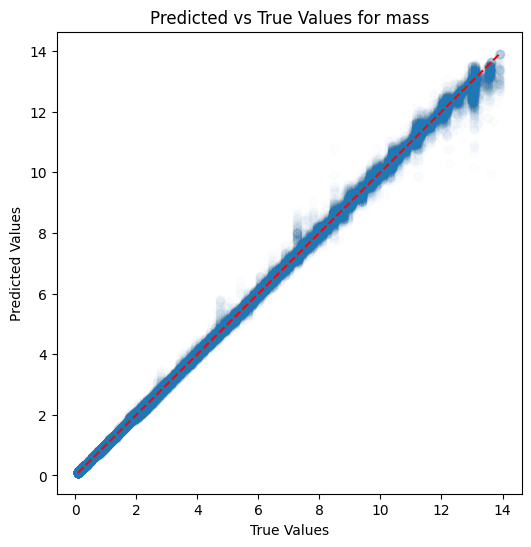

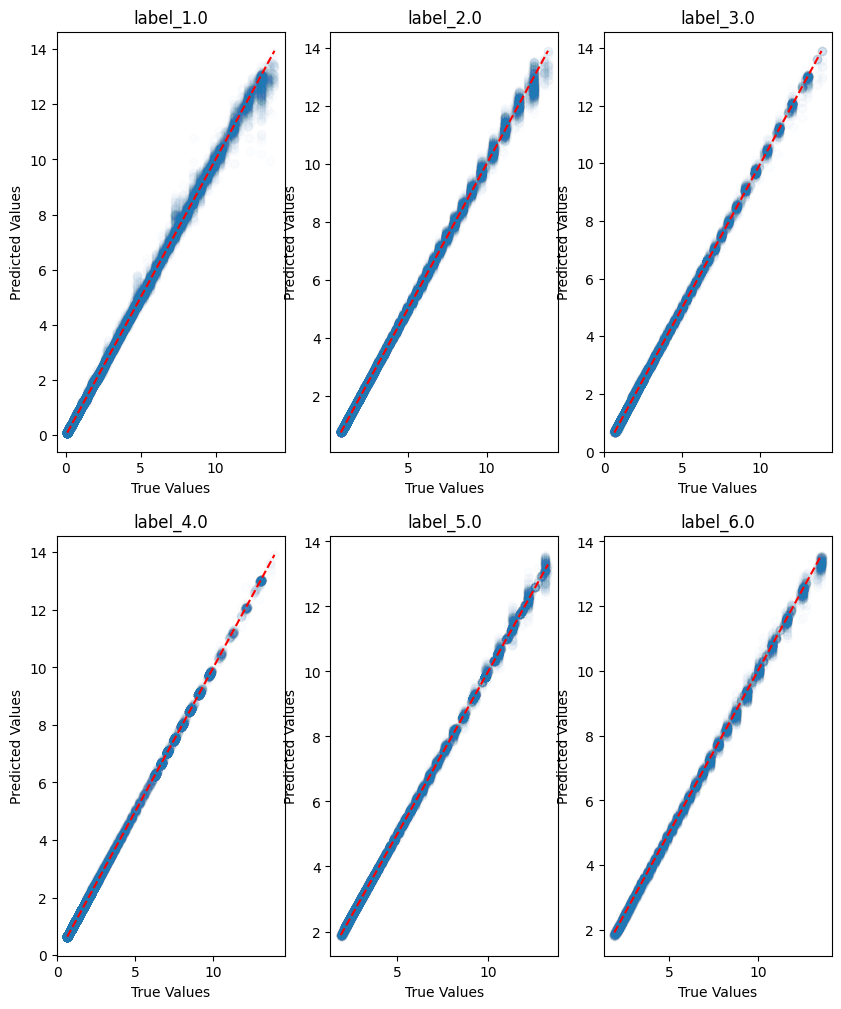

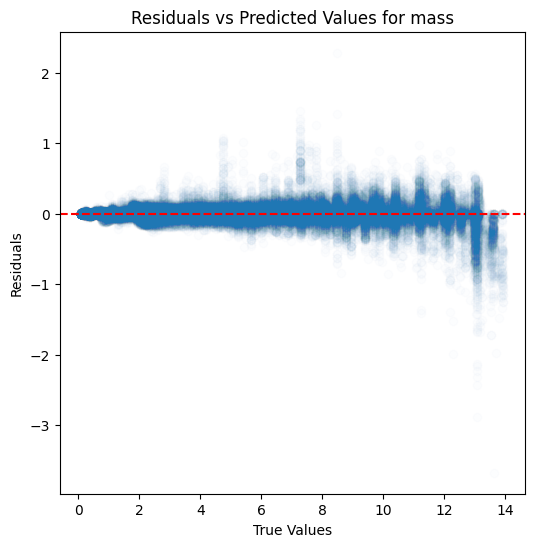

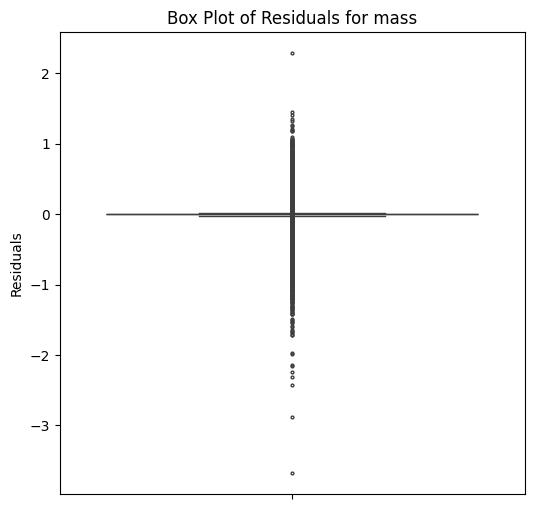

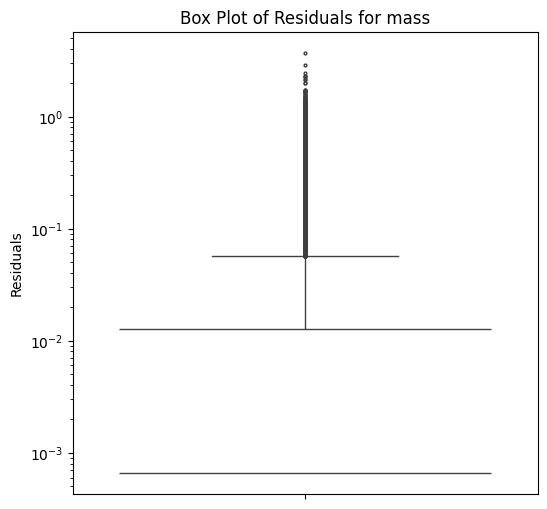

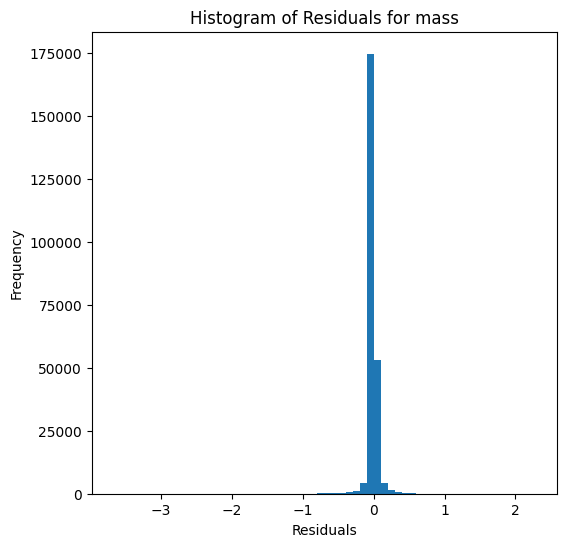

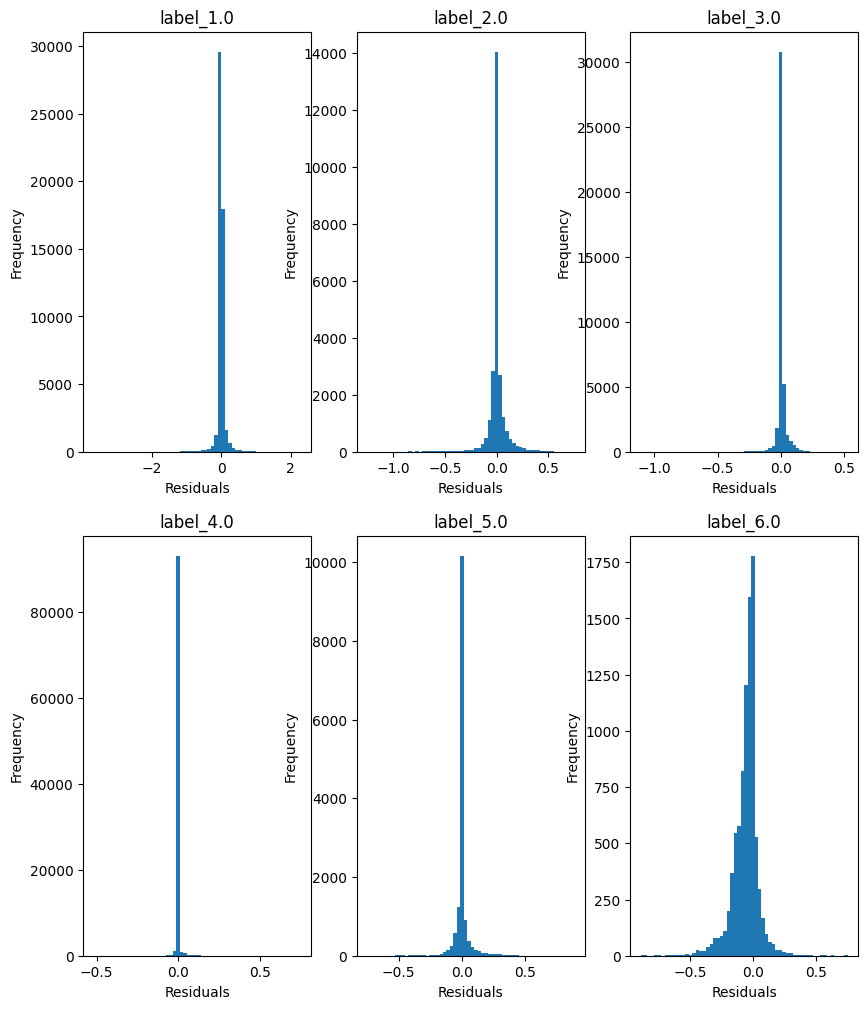

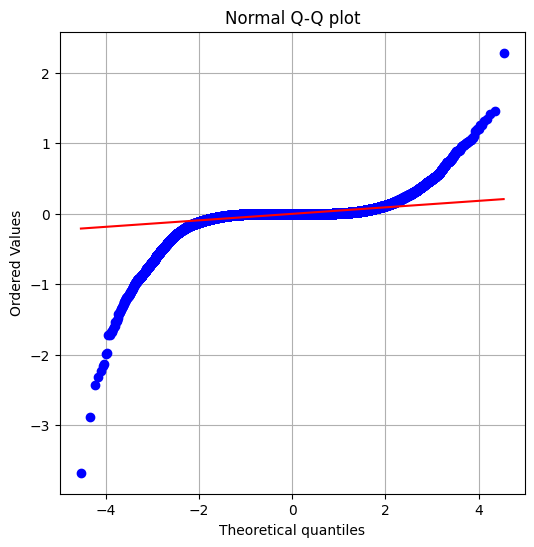

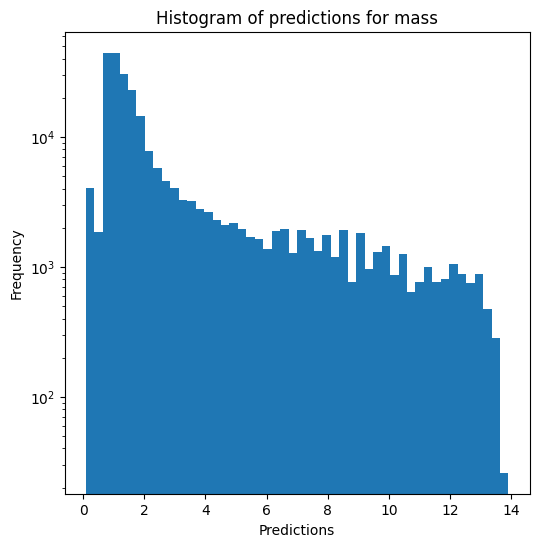

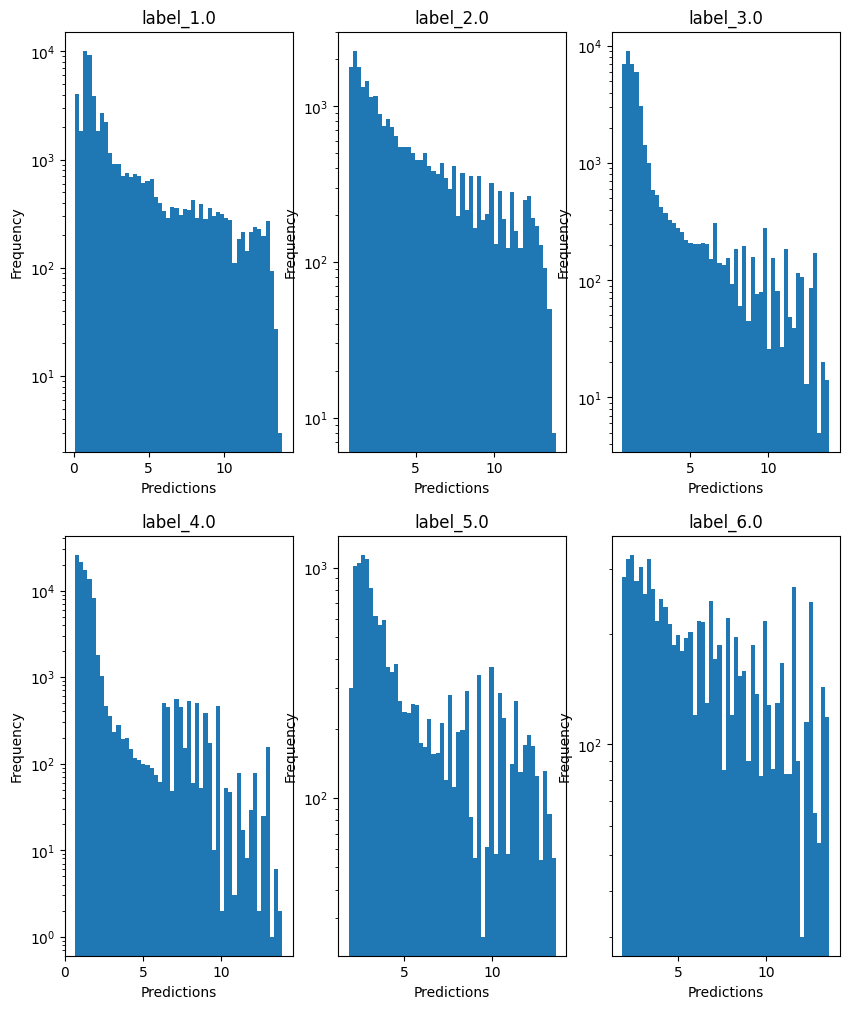

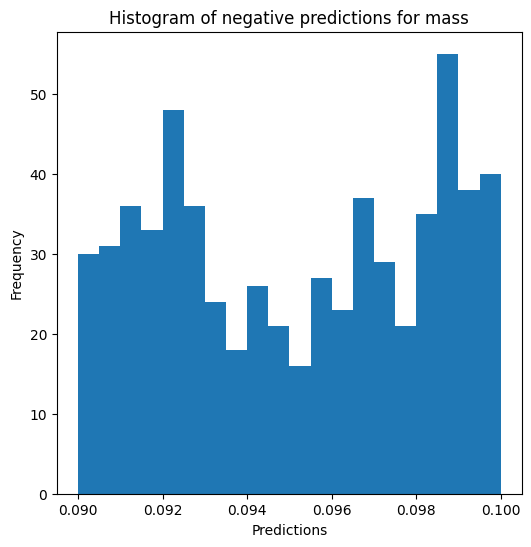


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9995123347937918
  RMSE :  0.008093210478761433
  MAE :  0.004987085051407938
  MedAE :  0.002703907952640597
  CORR :  0.9997569535603915
  MAX_ER :  0.08713373403111768
  Percentiles : 
    75th percentile :  0.006921845014918548
    90th percentile :  0.01294035679946215
    95th percentile :  0.017589843269956607
    99th percentile :  0.029018868244255574

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9994831993642557
  RMSE :  0.012367422447291557
  MAE :  0.006376654636995695
  MedAE :  0.003917510294363491
  CORR :  0.9997645665627639
  MAX_ER :  0.2783732779571493
  Percentiles : 
    75th percentile :  0.0077276938890119
    90th percentile :  0.013161194754258292
    95th percentile :  0.018043477502730065
    99th percentile :  0.0452121987449272

radius results for the 

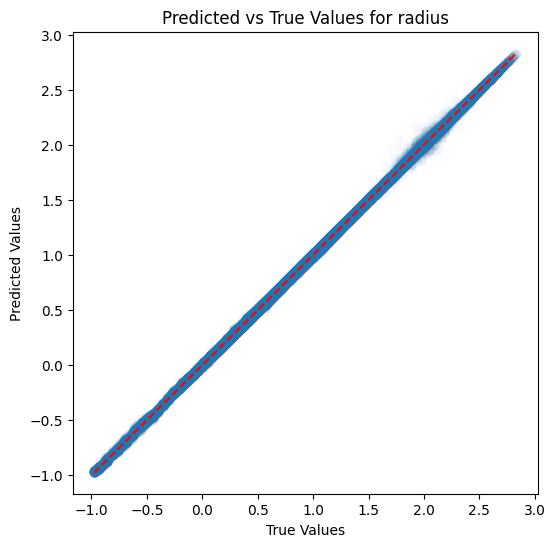

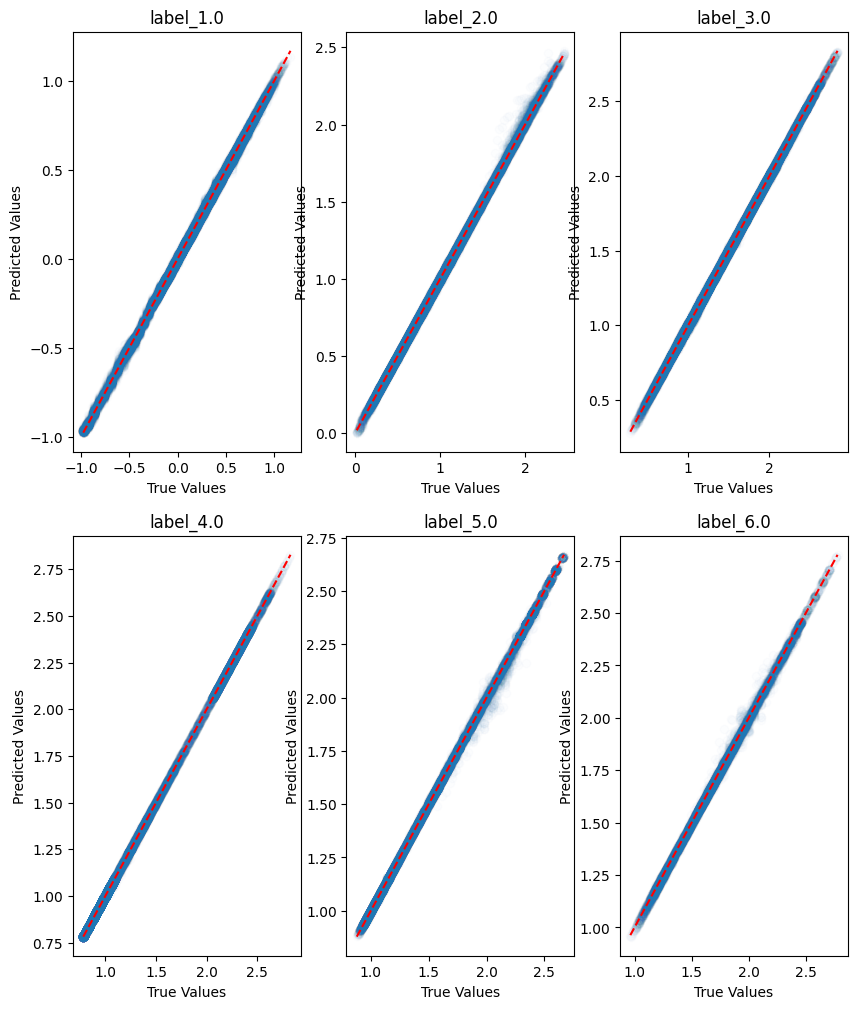

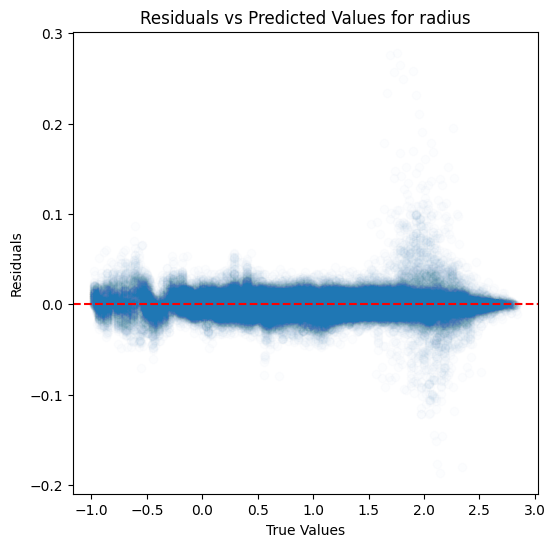

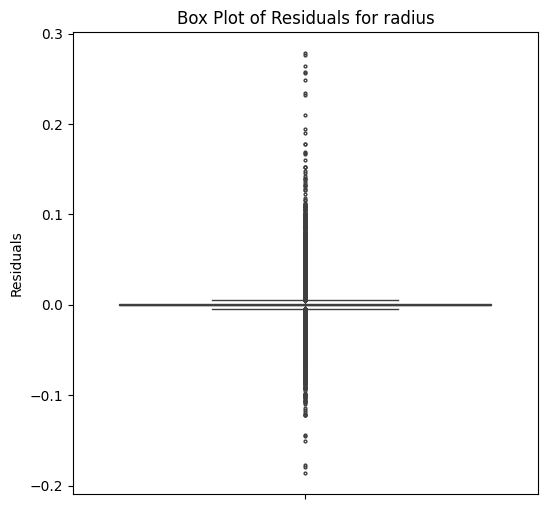

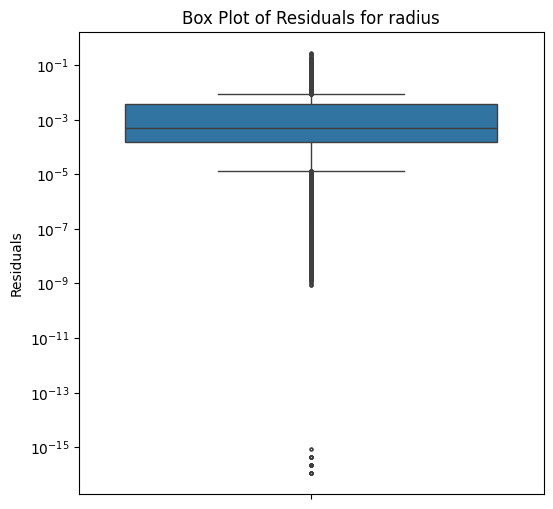

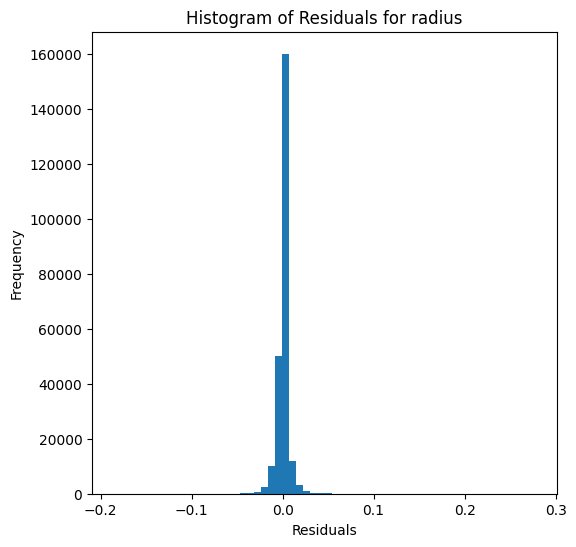

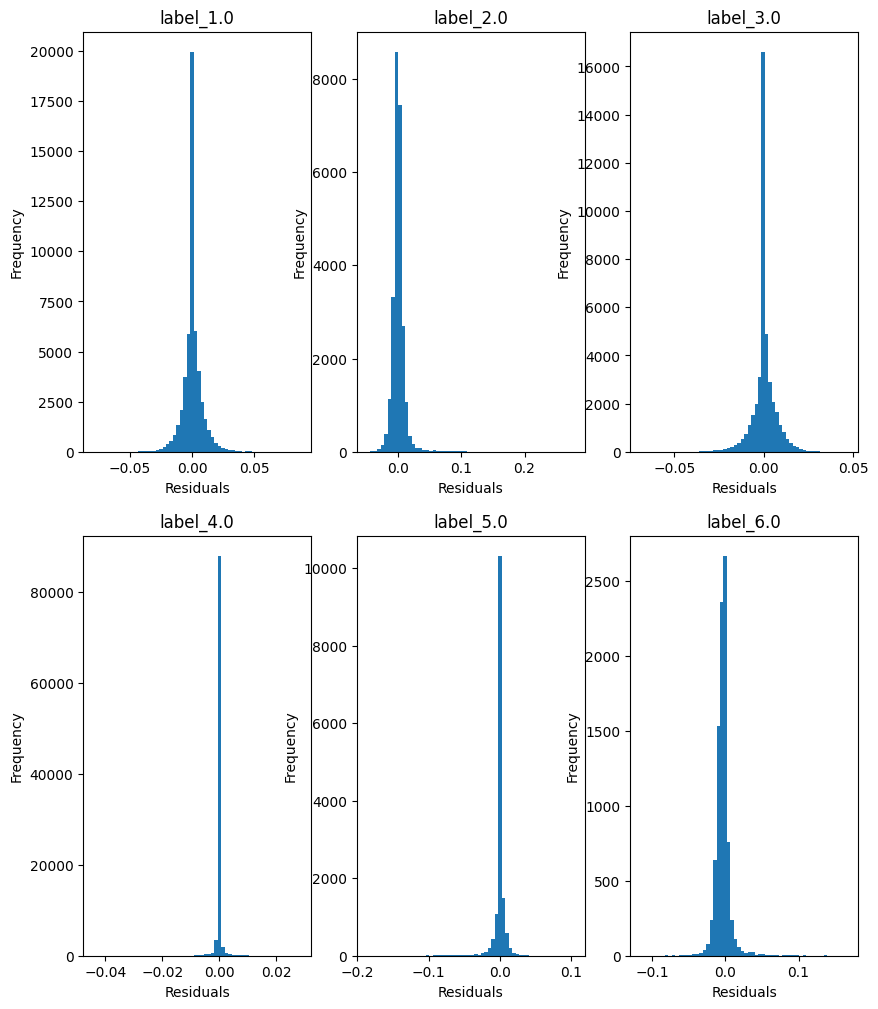

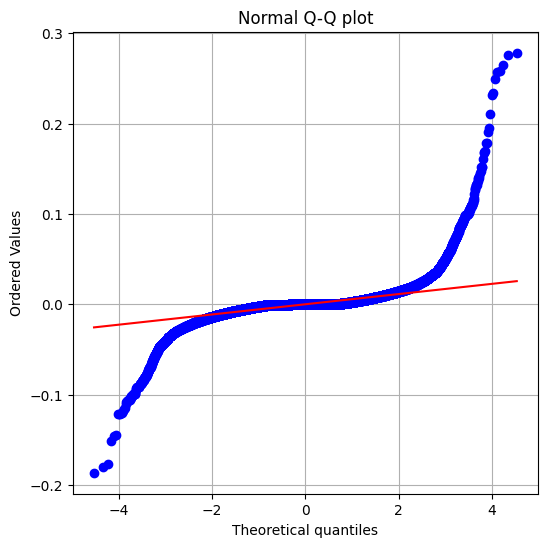

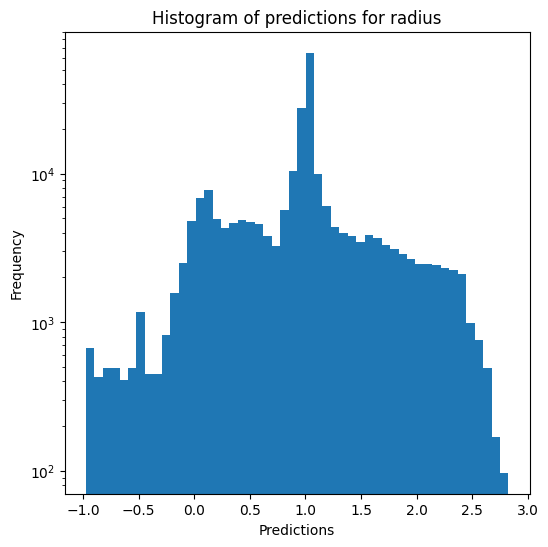

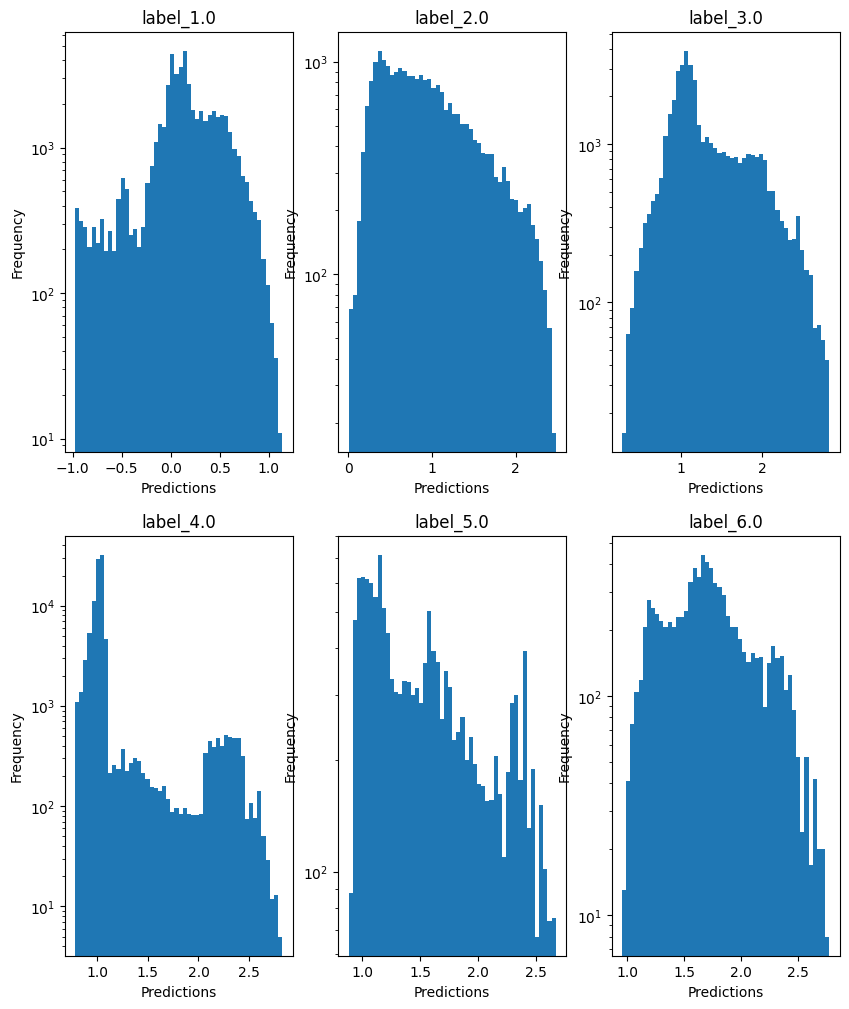

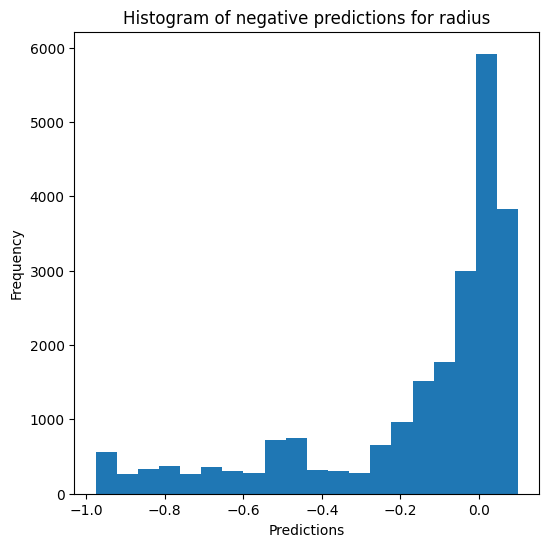

Saving predictions and results...


In [17]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'ball_tree', 'leaf_size': 50, 'n_neighbors': 5, 'p': 1.0, 'weights': 'distance'}

print(path_to_results)
dt_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, **best_params_KNN)